In [1]:
# Threading
# To start Julia with 8 threads on PC, open anaconda prompt and run <set JULIA_NUM_THREADS=8>, then run <jupyter notebook>
# ENV["JULIA_NUM_THREADS"] = 8 # Don't need to run on mac - set nthreads in VScode
Threads.nthreads()

8

In [2]:
# import Pkg; Pkg.develop(path="/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl")
using IRQIV
import PyPlot as plt
import Statistics, NaNStatistics, LinearAlgebra
import CSV
using DataFrames, Dates, TimeZones
plt.pygui(false) # sets plots to popup instead of inline

# Path to parent directory
CACO_dir = dirname(dirname(dirname(@__FILE__)))

"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO"

In [3]:
# Global camera parameters
fl = 1214.2857142857144 # In pixels - from Seth
include(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl")
Camera = IRQIV.FLIR_SC8303_17mm
ι = IRQIV.IntrinsicCalibrationParameters(Camera)
ats_year = 2022
ft_to_m = 0.3048

0.3048

In [4]:
using Interpolations

# Import thermistor data from field campaign

# ChatGPT function to find nearest thermistor times to each ATS file (for WSE)
function find_nearest_time_indices(irregular_times, regular_times)
    nearest_indices = [argmin(abs.(time .- regular_times)) for time in irregular_times]
    return nearest_indices
end

thermpath = joinpath(CACO_dir, "2022/Thermistor/P6_CACO_July_2022_truncated.txt")
therm = CSV.read(thermpath, delim = ',', DataFrame)
# # 360 lines per hour, 8640 lines per day
river_therm_cam_offset = (sqrt(9^2-2^2) + 1/3 + 7) * ft_to_m
bay_therm_cam_offset = 209/12*ft_to_m

therm[!,3] = Dates.Date.(therm[!,3], " dd u YYYY")
therm_datetime = Dates.DateTime.(therm[!,3], therm[!,4])
therm = hcat(therm, therm_datetime)
rename!(therm,[:TemperatureC, :PressureM, :Date, :Time, :DateTime])

# Find times when thermistor was deployed
therm_time_extrema = extrema(therm.DateTime)

# Import flux tower met station data for atmospheric pressure correction 
atmP_df = CSV.read(joinpath(CACO_dir, "2022/Thermistor", "2021_HRPhrag_BARO_111721_Append_2022-10-21_17-51-24-365.csv"), DataFrame, header = 70)
atmP_DateTimeUTC = Dates.DateTime.(Dates.Date.(atmP_df.Date, "mm/dd/yy") + 
    Dates.Time.(strip.(atmP_df."Time (UTC)"), "HH:MM:SS p "))
# Clean data and convert to local time zone
atmP_df.DateTimeET = Dates.DateTime.(TimeZones.astimezone.(
    TimeZones.ZonedDateTime.(atmP_DateTimeUTC, TimeZones.tz"UTC"), 
        TimeZones.tz"America/New_York")) # Convert UTC to local eastern time and remove time zone from DateTime
# Filter met station data overlapping with thermistor
atmP_df = atmP_df[findall(x -> x >= therm_time_extrema[1]-Dates.Second(10) && 
    x < therm_time_extrema[2]+Dates.Minute(13), atmP_df.DateTimeET),:] # Get data on either end of thermistor

# Interpolate met station data to thermistor frequency
atmP_seconds = Float64.((atmP_df.DateTimeET .- atmP_df.DateTimeET[1]) ./ Dates.Second(1))
atmP_interp_times = collect(therm.DateTime[1]:Dates.Second(10):therm.DateTime[end]) # Interpolate to same times as therm
atmP_interp_seconds = Float64.((atmP_interp_times .- atmP_df.DateTimeET[1]) ./ Dates.Second(1))
interp_fxn = LinearInterpolation((atmP_seconds,), atmP_df."Barometric Pressure (PSI)               ", extrapolation_bc=Flat())
atmP_interpolated = interp_fxn.(atmP_interp_seconds)

# Thermistor follows air pressure data before deployment, not so much after (out of water ind 17863)
Pcomp_inds = 169:863

PSI_to_dbar = 0.68948
# Calculate mean of pre-deployment ambient air pressure for thermistor and weather station
thermP_ambient_mean = Statistics.mean(therm.PressureM[Pcomp_inds])  # in dbar
metstation_ambient_mean = Statistics.mean(atmP_interpolated[Pcomp_inds])  # in PSI 

# Subtract met station mean pressure pre-deployment from met station time series and convert to dbar
atmP_interp_delta = (atmP_interpolated .- metstation_ambient_mean) .* PSI_to_dbar

# Change thermistor elevation relative to camera
therm_moved_datetime = Dates.DateTime(Dates.Time("08:12:00", "HH:MM:SS") + Dates.Date("2022-07-14", "yyyy-mm-dd"))
therm_moved_bool = (therm.DateTime .== therm_moved_datetime) 
therm_moved_idx = findall(x->x==1, therm_moved_bool)[]

therm.Pcorrected = therm.PressureM .- thermP_ambient_mean
therm.Pcorrected[therm_moved_idx:end] .*= (1026/1000) # Account for density of seawater on downstream side
therm.Pcorrected .-= atmP_interp_delta
thermP = therm.Pcorrected

plt.rc("font", size=14) 
plt.figure() # Plot comparison of mean-subtracted thermistor air pressure with interpolated met station pressure
# plt.plot(therm.DateTime[Pcomp_inds], therm.PressureM[Pcomp_inds].-Statistics.mean(therm.PressureM[Pcomp_inds]))
# plt.plot(therm.DateTime[Pcomp_inds], atmP_interpolated[Pcomp_inds].-Statistics.mean(atmP_interpolated[Pcomp_inds]))
# plt.scatter(atmP_interpolated[Pcomp_inds], therm.PressureM[Pcomp_inds]) # Look at time relationship between pressure readings
# plt.plot(thermP[17863:end])# Visualize thermistor data before and after deployment
# plt.plot(thermP[Pcomp_inds]) 
# plt.plot(atmP_interp_delta)
plt.plot(therm.DateTime, therm.Pcorrected)
plt.xticks(rotation=45)

thermZ = bay_therm_cam_offset.-thermP[1:therm_moved_idx] # vertical offset from camera to thermistor - 
thermZ = append!(thermZ, bay_therm_cam_offset.-thermP[therm_moved_idx+1:end])
therm = hcat(therm, thermZ)
rename!(therm, :x1 => :WaterDistanceFromCameraM)

# plt.gcf()


Row,TemperatureC,PressureM,Date,Time,DateTime,Pcorrected,WaterDistanceFromCameraM
,Float64,Float64,Date,Time,DateTime,Float64,Float64
1,25.9042,-0.049,2022-07-13,06:30:10,2022-07-13T06:30:10,-0.0128343,5.32143
2,25.9081,-0.049,2022-07-13,06:30:20,2022-07-13T06:30:20,-0.0128266,5.32143
3,25.9097,-0.049,2022-07-13,06:30:30,2022-07-13T06:30:30,-0.012819,5.32142
4,25.9091,-0.049,2022-07-13,06:30:40,2022-07-13T06:30:40,-0.0128113,5.32141
5,25.9086,-0.049,2022-07-13,06:30:50,2022-07-13T06:30:50,-0.0128036,5.3214
6,25.9086,-0.049,2022-07-13,06:31:00,2022-07-13T06:31:00,-0.012796,5.3214
7,25.9087,-0.049,2022-07-13,06:31:10,2022-07-13T06:31:10,-0.0127883,5.32139
8,25.9077,-0.049,2022-07-13,06:31:20,2022-07-13T06:31:20,-0.0127807,5.32138
9,25.9073,-0.049,2022-07-13,06:31:30,2022-07-13T06:31:30,-0.012773,5.32137


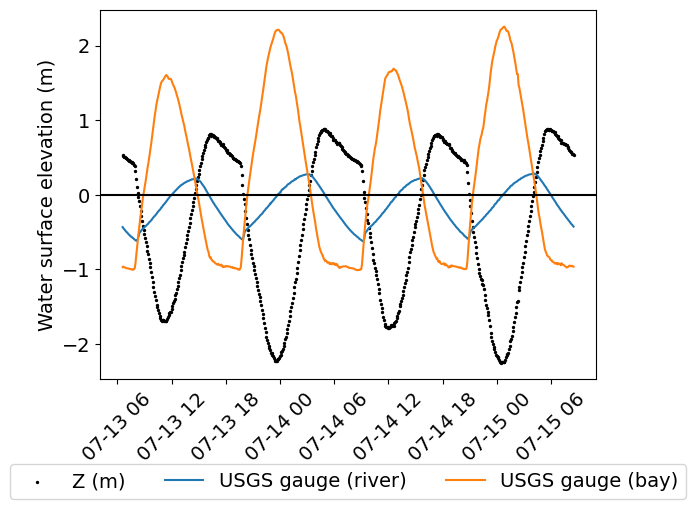

In [5]:
# Import USGS tide gauge data to relate thermistor to tide gauge
plt.close("all")

USGS_tidegauge = CSV.read(joinpath(CACO_dir, "2022/Analysis/Modeling/WL_model_inputs", "HRE_CNRD_USGS_011058798.csv"), DataFrame, header = 28)[2:end, :]

USGS_bayH = parse.(Float64, USGS_tidegauge."218558_00065") .* ft_to_m
USGS_riverH = parse.(Float64, USGS_tidegauge."66254_00065") .* ft_to_m
USGS_datetime = Dates.DateTime.(USGS_tidegauge."datetime", "m/d/y H:M")

# ATS_firstframe_time = IRQIV.ats_ts(I1images)[1]
# find_nearest_time_indices(ATS_time_extrema, USGS_datetime)

# Converting thermistor vertical offset to tide gauge

# Function to find indices of local abs(H) minima -> zero-crossings 
function local_minima_indices(vec::Vector{Float64}; threshold::Float64 = 0.2)
    absvec = abs.(vec)
    inds = [i for i in 2:length(absvec)-1 if absvec[i] < absvec[i-1] && absvec[i] < absvec[i+1] && absvec[i] < threshold]
    return inds
end

# Find overlap between tide gauge and thermistor (proxy for experiment)
therm_overlap_inds = findall(x -> x >= therm_time_extrema[1] && x <= therm_time_extrema[2], USGS_datetime)
USGS_deltaH = [USGS_datetime[therm_overlap_inds], USGS_riverH[therm_overlap_inds] .- USGS_bayH[therm_overlap_inds]]
# Deployed in river side
therm_overlap_inds_river = findall(x -> x >= therm_time_extrema[1] && x < therm_moved_datetime, USGS_datetime)
# Deployed in bay side 
therm_overlap_inds_bay = findall(x -> x > therm_moved_datetime && x <= therm_time_extrema[2], USGS_datetime)
# In subset of original indices, find local minima for river/bay side data
riverH_min_inds = therm_overlap_inds_river[local_minima_indices(USGS_riverH[therm_overlap_inds_river])]
riverH_local_mins = USGS_riverH[riverH_min_inds]
bayH_min_inds = therm_overlap_inds_bay[local_minima_indices(USGS_bayH[therm_overlap_inds_bay])]
bayH_local_mins = USGS_bayH[bayH_min_inds]

# Compare thermistor to tide gauge at multiple points immediately before camera to thermistor was measured
river_offset_times = [USGS_datetime[riverH_min_inds[4]],
    Dates.DateTime("2022-07-14T03:30:00"),
    Dates.DateTime("2022-07-14T06:30:00"),
    Dates.DateTime("2022-07-14T07:30:00"),]

river_offset_inds_USGS = findall(x -> x in river_offset_times, USGS_datetime)
river_offset_inds_therm = findall(x -> x in river_offset_times, therm.DateTime)
river_therm_gauge_offset = Statistics.mean(therm.Pcorrected[river_offset_inds_therm] .- USGS_riverH[river_offset_inds_USGS])

# On bay side, offset is around 0.9 near second peak, but shifts around first time in offset vector:
bay_offset_times = [Dates.DateTime("2022-07-15T04:05:00"),
    Dates.DateTime("2022-07-15T05:00:00"),
    Dates.DateTime("2022-07-15T06:30:00"),
    Dates.DateTime("2022-07-15T07:30:00")]
# Vertical distance from camera to thermistor measured at end on both sides according to notes, offset appears ~constant at these times
bay_offset_inds_USGS = findall(x -> x in bay_offset_times, USGS_datetime)
bay_offset_inds_therm = findall(x -> x in bay_offset_times, therm.DateTime)
bay_therm_gauge_offset = Statistics.mean(therm.Pcorrected[bay_offset_inds_therm] .- USGS_bayH[bay_offset_inds_USGS])

# Subtract gauge to therm offset from camera to thermistor distance
river_gauge_cam_offset = river_therm_cam_offset - river_therm_gauge_offset
bay_gauge_cam_offset = bay_therm_cam_offset - bay_therm_gauge_offset

# Calculate water distance from camera
river_gauge_dist_from_cam = [USGS_datetime[therm_overlap_inds_river], 
    river_gauge_cam_offset .- USGS_riverH[therm_overlap_inds_river]]
bay_gauge_dist_from_cam = [USGS_datetime[therm_overlap_inds_bay], 
    bay_gauge_cam_offset .- USGS_bayH[therm_overlap_inds_bay]]

inflow_time_inds = findall(x -> DateTime("2022-07-14T18:00:00") <= x <= DateTime("2022-07-14T23:59:00"), USGS_deltaH[1])
inflow_tide_inds = findall(x -> x < 0, USGS_deltaH[2][inflow_time_inds])
inflow_tide_inds = inflow_time_inds[inflow_tide_inds] # Get back into original indices 
inflow_tide_times = USGS_deltaH[1][inflow_tide_inds]

plt.figure()
# plt.plot(USGS_datetime[therm_overlap_inds_river], abs.(USGS_riverH[therm_overlap_inds_river]))
# plt.plot(USGS_datetime[therm_overlap_inds_bay], abs.(USGS_bayH[therm_overlap_inds_bay]))
# plt.plot(therm.DateTime, thermP)
# plt.axvline.(USGS_datetime[riverH_min_inds])
# plt.axvline.(USGS_datetime[bayH_min_inds])
# plt.plot(therm.DateTime, therm.Pcorrected)
# plt.scatter(USGS_datetime[therm_overlap_inds_river], USGS_riverH[therm_overlap_inds_river])
# plt.scatter(USGS_datetime[therm_overlap_inds_bay], USGS_bayH[therm_overlap_inds_bay])
# plt.axvline.(river_offset_times)
# plt.axvline.(bay_offset_times)
# plt.plot(therm.DateTime, thermZ)
# plt.plot(river_gauge_dist_from_cam[1], river_gauge_dist_from_cam[2])
# plt.plot(bay_gauge_dist_from_cam[1], bay_gauge_dist_from_cam[2])
# plt.ylabel("Water surface distance from camera (m)")
# plt.legend(["Thermistor", "USGS gauge (river)", "USGS gauge (bay)"])
plt.scatter(USGS_deltaH[1], USGS_deltaH[2], color = "black", s = 2)
plt.plot(USGS_datetime[therm_overlap_inds], (USGS_riverH[therm_overlap_inds]))
plt.plot(USGS_datetime[therm_overlap_inds], (USGS_bayH[therm_overlap_inds]))
plt.legend(["Z (m)", "USGS gauge (river)", "USGS gauge (bay)"], 
    loc = "lower center", bbox_to_anchor=(0.5, -0.35), ncol=3)
plt.ylabel("Water surface elevation (m)")
plt.axhline(0, color = "black")
plt.xticks(rotation=45)
plt.gcf()



In [6]:
# INCORPORATE GEOREFERENCING - bay side (same code as river)
import Geodesy

# Import dike resurvey data from May 2023
resurvey_dir = joinpath(CACO_dir, "2023/5_23_SiteVisit/Georeferencing/Leica/M_CNRD.TXT")

CNRD_resurvey = CSV.read(resurvey_dir, DataFrames.DataFrame) # Total station recorded in survey ft!!
US_GCP_xyz_resurvey = [CNRD_resurvey[2:7,2] CNRD_resurvey[2:7,3] CNRD_resurvey[2:7,4]] .* ft_to_m
DS_GCP_xyz_resurvey = [CNRD_resurvey[8:12,2] CNRD_resurvey[8:12,3] CNRD_resurvey[8:12,4]] .* ft_to_m

# Convert to geospatial coords using GPS data
antenna_csv = CSV.read(joinpath(CACO_dir, "2023/5_23_SiteVisit/Georeferencing/InertialSense/20230515_173251_base/LOG_SN40107_20230515_173251_0001_DID_GPS1_RTK_POS.csv"), DataFrames.DataFrame)
antenna_lla = Geodesy.LLA(Statistics.mean(antenna_csv."lla[0]"), Statistics.mean(antenna_csv."lla[1]"), Statistics.mean(antenna_csv."lla[2]"))
antenna_utm = Geodesy.UTMZ(antenna_lla, Geodesy.wgs84)

# US_GCP_utm_resurvey = US_GCP_xyz_resurvey + [antenna_utm.x antenna_utm.y antenna_utm.z]
US_GCP_utm_resurvey = US_GCP_xyz_resurvey .+ [antenna_utm.x antenna_utm.y antenna_utm.z] # Add UTM position of antenna to all relative points in m
DS_GCP_utm_resurvey = DS_GCP_xyz_resurvey .+ [antenna_utm.x antenna_utm.y antenna_utm.z] # Add UTM position of antenna to all relative points in m

# Incorporate board georef on bay side:
DS_board_o1 = CSV.read(joinpath(CACO_dir, "2022/CACO_GPS/20220714_201935_DS_GCPo1/LOG_SN40107_20220714_201935_0001_DID_GPS1_POS.csv"), DataFrame)
DS_board_o1 = DS_board_o1[:,[9, 10, 11, 16]] # lla 1-3 + status (code 0x00000C00 = RTK_FIX according to pg. 138: https://docs.inertialsense.com/user-manual/reference/user_manual_pdf/InertialSenseDocs.pdf)
DS_board_o1_fix = filter(row->any(occursin.("C", row.status[end-2:end-2])), DS_board_o1) # from https://discourse.julialang.org/t/better-way-to-filter-strings-from-dataframe/88012
DS_board_o4 = CSV.read(joinpath(CACO_dir, "2022/CACO_GPS/20220714_210002_DS_GCPo4/LOG_SN40107_20220714_210002_0001_DID_GPS1_POS.csv"), DataFrame)
DS_board_o4 = DS_board_o4[:,[9, 10, 11, 16]] 
DS_board_o4_fix = filter(row->any(occursin.("C", row.status[end-2:end-2])), DS_board_o4) 
DS_board_o5 = CSV.read(joinpath(CACO_dir, "2022/CACO_GPS/20220714_211156_DS_GCPo5/LOG_SN40107_20220714_211156_0001_DID_GPS1_POS.csv"), DataFrame)
DS_board_o5 = DS_board_o5[:,[9, 10, 11, 16]] 
DS_board_o5_fix = filter(row->any(occursin.("C", row.status[end-2:end-2])), DS_board_o5) 

# o4 & o5 did not get to RTK_FIX but still look very steady - average!
# plt.close("all")
# plt.plot(DS_board_o1_fix[:,1])
# #plt.plot(DS_board_o1_fix[:,2])
# plt.plot(DS_board_o4[:,1])
# #plt.plot(DS_board_o4[:,2])
# #plt.plot(DS_board_o4[:,3])
# plt.plot(DS_board_o5[:,1])
# #plt.plot(DS_board_o5[:,2])
# #plt.plot(DS_board_o5[:,3])

# Check drift of non-fix GPS 
maximum(DS_board_o4[:,1]) - minimum(DS_board_o4[:,1])
maximum(DS_board_o4[:,2]) - minimum(DS_board_o4[:,2])
maximum(DS_board_o4[:,3]) - minimum(DS_board_o4[:,3])
maximum(DS_board_o5[:,1]) - minimum(DS_board_o5[:,1])
maximum(DS_board_o5[:,2]) - minimum(DS_board_o5[:,2])
maximum(DS_board_o5[:,3]) - minimum(DS_board_o5[:,3])
# Drift is minimal in x/y but large in z

# Compare averages/minimums
DS_board_o1_avg = Statistics.mean.(eachcol(DS_board_o1_fix[:,1:3])) # Only fix GPS data used for x-y coords
DS_board_o4_avg = Statistics.mean.(eachcol(DS_board_o4[:,1:3]))
DS_board_o5_avg = Statistics.mean.(eachcol(DS_board_o5[:,1:3]))
DS_board_o5_avg[3] = minimum(DS_board_o5[:,3])
# dump(DS_board_o1_avg[3])
# dump(DS_board_o4_avg[3])
# dump(DS_board_o5_avg[3])
# o5 minimum is closer to mean of o1 & o4, numbers look reasonable relative to DS_GCP_utm_resurvey

# Convert LLA to UTM
DS_board_o1_utm = Geodesy.UTMZ(Geodesy.LLA(DS_board_o1_avg[1], DS_board_o1_avg[2], DS_board_o1_avg[3]), Geodesy.wgs84)
DS_board_o4_utm = Geodesy.UTMZ(Geodesy.LLA(DS_board_o4_avg[1], DS_board_o4_avg[2], DS_board_o4_avg[3]), Geodesy.wgs84)
DS_board_o5_utm = Geodesy.UTMZ(Geodesy.LLA(DS_board_o5_avg[1], DS_board_o5_avg[2], DS_board_o5_avg[3]), Geodesy.wgs84)
DS_board_utm = [DS_board_o1_utm.x DS_board_o1_utm.y DS_board_o1_utm.z
DS_board_o4_utm.x DS_board_o4_utm.y DS_board_o1_utm.z
DS_board_o5_utm.x DS_board_o5_utm.y DS_board_o1_utm.z]

# Add board GPS (first orientation only) to resurvey vector:
DS_GCP_utm_combined = vcat(DS_GCP_utm_resurvey, DS_board_utm[1,:]')

plt.plot(DS_board_o1_fix[:,3])
plt.gcf()

# Georeferencing very sensitive to board z-coordinate, select from antenna time series to improve reprojection:
DS_GCP_utm_combined[6,3] = minimum(DS_board_o1[:,3]) # Can tweak this up to +>1m to adjust extent of FOV outward from dike
DS_GCP_utm_combined

┌ Warning: thread = 1 warning: parsed expected 6 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV /Users/evanheberlein/.julia/packages/CSV/OnldF/src/file.jl:578


6×3 Matrix{Float64}:
      4.11745e5  4.64267e6  -25.1365
      4.11745e5  4.64267e6  -25.5898
      4.11745e5  4.64267e6  -26.0746
      4.11744e5  4.64268e6  -26.2701
 411744.0        4.64268e6  -27.268
      4.11743e5  4.64267e6  -27.716

ExtrinsicCalibrationParameters
  φ: Float64 -0.7853981633974483
  τ: Float64 -2.8654956341943567
  σ: Float64 0.13909594148207133
  f: Float64 1214.2857142857144
  x_c: Float64 411743.0601037771
  y_c: Float64 4.642674180709229e6
  z_c: Float64 -24.093384677637545


┌ Warning: Too few BHPHeaders to calculate fps!
└ @ IRQIV.FLIRATSFiles /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/src/FLIRATSFiles.jl:415
┌ Info: (411744.63910856453, 411743.2911857274)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411744.62618504453, 411743.4029594806)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411744.63673112454, 411743.50989988155)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411743.92697384453, 411743.17484681663)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411744.04889384453, 411743.5643500467)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411742.

Finished extrinsic calibration:, 18 iterations, max(|ε|)=1e-10, rms(ε₁-ε₀)=2e-11
ExtrinsicCalibrationParameters
  φ: Float64 -0.7853981633974483
  τ: Float64 -2.8654956341943567
  σ: Float64 0.13909594148207133
  f: Float64 1214.2857142857144
  x_c: Float64 411743.0601037771
  y_c: Float64 4.642674180709229e6
  z_c: Float64 -24.093384677637545
dump(χinitial_ds) = nothing
ExtrinsicCalibrationParameters
  φ: Float64 -1.4304548190321396
  τ: Float64 -2.821451967980822
  σ: Float64 0.38292668649731326
  f: Float64 1280.579618118304
  x_c: Float64 411744.6774145493
  y_c: Float64 4.642674015771329e6
  z_c: Float64 -23.93024861855872
dump(χcalculated) = nothing
φ diff (degrees) -  36.95902391469154
τ diff (degrees) -  -2.5235161883184856
σ diff (degrees) -  -13.970472604903899
f diff -  -66.29390383258965
x_c diff (meters) -  -1.6173107721842825
y_c diff (meters) -  0.16493789944797754
z_c diff (meters) -  -0.16313605907882334


┌ Info: Initial guess, χinitial:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sZmlsZQ==.jl:60
┌ Info: Calibrated values, χcalculated:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sZmlsZQ==.jl:63
┌ Info: Difference between calibrated value and initial guess:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sZmlsZQ==.jl:67
┌ Info: (411744.63910856453, 411744.61052058137)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411744.62618504453, 411744.66087158065)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411744.63673112454, 411744.7066817419)
└ @ Ma

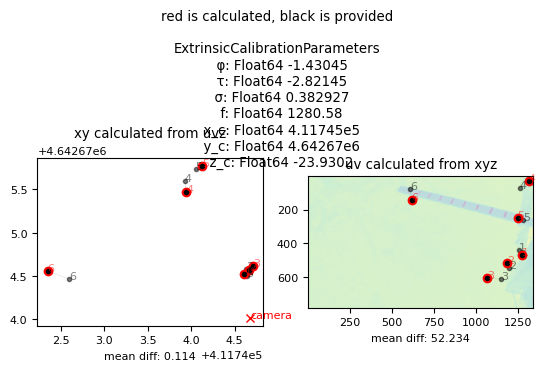

In [7]:
# Camera location calibration setup - BAY SIDE:
camll_ds = [41.931099, -70.064524] # Guess from Google maps
# Have measurement of camera to deck (?) for US side
camelev_ds = DS_GCP_utm_resurvey[3,3] + 6.5*ft_to_m # Use lower bolt elevation w/ offset - [old: Guess DS camera offset from board GCP elev based on photos]
cam_LLA_ds = Geodesy.LLA(camll_ds[1], camll_ds[2], camelev_ds)
cam_UTM_ds = Geodesy.UTMZ(cam_LLA_ds, Geodesy.wgs84)

# # Camera angle approximation:
# azimuth_ds = 315 * (pi/180)  # Guess from google maps
# tilt_ds = atan(34/120) # atan(120/34)  # Approx. from photo
# roll_ds = atan(7/50) # ''
# azimuth_ds = 315 * (pi/180)  # Guess from google maps
azimuth_ds = deg2rad(315-360) # updated 12/3/24
# tilt_ds = atan(34/120) # atan(120/34)  # Approx. from photo
tilt_ds = -pi + atan(34/120) # updated 12/3/24 - negative from vertical
roll_ds = atan(7/50) # ''

# Initial guess of camera's extrinsic parameters:
χinitial_ds = IRQIV.ExtrinsicCalibrationParameters(azimuth_ds, tilt_ds, roll_ds, fl, cam_UTM_ds.x, cam_UTM_ds.y, cam_UTM_ds.z)
dump(χinitial_ds)

# UTM coordinates of GCPs:
# TrueGCPxyz = [GCPxyz_us[:,1] GCPxyz_us[:,2] GCPzg_us]

# Pixel coordinates of GCPs, before accounting for radial distortion:
# File 3582 can see bolt without grass in the way
DistortedImageGCPuv_ds  = [1255 443 # 5H
                        1200 549 # 5M
                        1155 615 # 5L
                        1257 73 # 6H
                        1278 264 # 6L
                        606 71] # board o1
                        # 516 366 # board o4
                        # 388 716] # board o5

## Remove radial distortion from GCP target coordinates:
TrueGCPuv_ds = hcat(IRQIV.RemoveRadialDistortion(DistortedImageGCPuv_ds[:,1], DistortedImageGCPuv_ds[:,2], Camera)...)

# Optionally, load an IR image and plot it in the background:
FLIR_filename_ds = joinpath(raw"/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003482.ats")
IRimages_ds = LoadATSImageSequence(FLIR_filename_ds, 1, 2022)
plt.close("all")
plt.rc("font", size=8)
GraphicallyExploreInitialCalibrationGuess(TrueGCPuv_ds, DS_GCP_utm_combined, χinitial_ds, ι, IRimages_ds[1])
plt.gcf()

# Camera location calibration - BAY SIDE:

###############################################################################

χcalculated = ExtrinsicCalibration(
    TrueGCPuv_ds,
    DS_GCP_utm_combined,
    χinitial_ds,
    ι,
    MaxIterations = 50,
    PrintoutStats=true)

# ###############################################################################
@info "Initial guess, χinitial:"
@show dump(χinitial_ds)
# 
@info "Calibrated values, χcalculated:"
@show dump(χcalculated)
# 
# Describe how much the calibration changed each parameter:
@info "Difference between calibrated value and initial guess:"
for (i,x) in enumerate(fieldnames(typeof(χcalculated)))
    if i <= 3
        println("$x diff (degrees) -  $(rad2deg(getfield(χinitial_ds, x) - getfield(χcalculated, x)))")
    elseif i == 4
        println("$x diff -  $(getfield(χinitial_ds, x) - getfield(χcalculated, x))")
    else
        println("$x diff (meters) -  $(getfield(χinitial_ds, x) - getfield(χcalculated, x))")
    end
end

# Extract WSE from thermistor time series using ATS file timestamp
# ATS_file_time_ds = IRQIV.ats_ts(IRimages_ds)
# therminds_ds = find_nearest_time_indices(ATS_file_time_ds, therm.DateTime)
# WSE_mean_ATS_ds = χcalculated.z_c - therm.WaterDistanceFromCameraM[therminds_ds][1]
# RectParams_ds = IRQIV.ImageRectification.calculate_image_rectification(Camera.pixel_resolution, ι, χcalculated, WSE_mean_ATS_ds, interpolated_grid_spacing=.1)
# rectified_image_ds = RectParams_ds(IRimages_ds)

dlt_calculated = IRQIV.DLT(χcalculated, FLIR_SC8303_17mm)

plt.close("all")
plt.rc("font", size=8)
GraphicallyExploreInitialCalibrationGuess(TrueGCPuv_ds, DS_GCP_utm_combined, χcalculated, ι, IRimages_ds[1])
plt.gcf()



In [ ]:
# Fit streamlines to vector field functions

import DifferentialEquations
import StaticArrays

function meshgrid(x::AbstractVector, y::AbstractVector)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

function vector_field(u, p, t)
    x, y = u
    U = u_interp(x, y)
    V = v_interp(x, y)
    return StaticArrays.SA[U, V]
end

# Termination condition function
function terminate_at_bounds(u, t, integrator) # CHANGE FOR BAY
    x, y = u[2], u[1]
    
    # Check if out of image bounds
    if x < 1 || x > Img_dims[2] || y < 1 || y > Img_dims[1]
        return true
    end
    
    # Check if x is greater than the interpolated x-coordinate of us_shadow
    interpolated_x = shadow_interp(y)
    if x > interpolated_x # REVERSE 
        return true
    end
    
    return false
end

# Termination action function
function terminate_action!(integrator)
    DifferentialEquations.terminate!(integrator)
end

# Compute streamline function
function compute_streamline(start_point)
    # Convert the start point to a StaticArray
    start_point_sa = StaticArrays.SA[start_point[1], start_point[2]]

    # Set time span for the ODE solver
    tspan = (0.0, 200.0)  # Adjust the time span as needed

    # Create the DiscreteCallback
    cb = DifferentialEquations.DiscreteCallback(terminate_at_bounds, terminate_action!)

    # Define the ODEProblem with the initial condition and vector field
    prob = DifferentialEquations.ODEProblem(vector_field, start_point_sa, tspan)

    # Solve the ODEProblem with the callback
    sol = DifferentialEquations.solve(prob, DifferentialEquations.Tsit5(), callback=cb)

    # Extract and return the streamline coordinates
    streamline_coords = hcat(sol.u...)'
    # return streamline_coords
    coords = [(sol[1, i], sol[2, i]) for i in 1:length(sol.t)]
    return coords
    # print(streamline_coords)
end

# Function definitions - line identification

# Bresenham's line algorithm to get pixels for a line
function bresenham_line(x0, y0, x1, y1)
    pixels = []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = x0 < x1 ? 1 : -1
    sy = y0 < y1 ? 1 : -1
    err = dx - dy

    while true
        push!(pixels, (x0, y0))
        if x0 == x1 && y0 == y1
            break
        end
        e2 = 2 * err
        if e2 > -dy
            err -= dy
            x0 += sx
        end
        if e2 < dx
            err += dx
            y0 += sy
        end
    end
    return pixels
end

# Function to determine if a point is beyond the diagonal line
function left_of_diagonal(x, y, x_start, y_start, x_end, y_end)
    # Calculate the cross product to determine the side of the line
    line_value = (x_end - x_start) * (y - y_start) - (y_end - y_start) * (x - x_start)
    return line_value > 0  # Adjust depending on which side you want
end

# Function to calculate the slope of each labeled component if it exceeds the length threshold
function calculate_slope_for_components(labels::AbstractArray{Int}, num_components::Int, length_threshold::Int)
    slopes = Dict{Int, Float64}()
    x_lengths = Dict{Int, Float64}()
    
    for label in 1:num_components
        # Find the coordinates of all pixels in the component
        component_coords = findall(x -> x == label, labels)
        
        # Only consider the component if it exceeds the length threshold
        if length(component_coords) > length_threshold
            # Find the first and last pixel coordinates in the component
            first_pixel = component_coords[1]
            last_pixel = component_coords[end]
            
            # Calculate the slope between the first and last pixel
            x1, y1 = first_pixel[2], first_pixel[1]  # (x1, y1)
            x2, y2 = last_pixel[2], last_pixel[1]    # (x2, y2)
            
            if x2 != x1
                slope = (y2 - y1) / (x2 - x1)
            else
                slope = Inf  # Vertical line (undefined slope)
            end
            
            # Store the slope in a dictionary
            slopes[label] = slope
            x_lengths[label] = x2 - x1
        end
    end
    
    return slopes, x_lengths
end

function float_to_bool(edges::Matrix{Float64}, threshold::Float64)
    return edges .> threshold
end

# Label components function for diagonal relationships (instead of 4 connected)
function label_components_8_connected(edges::AbstractArray{Bool})
    rows, cols = size(edges)
    labels = zeros(Int, rows, cols)
    current_label = 0
    
    function in_bounds(r, c)
        return 1 <= r <= rows && 1 <= c <= cols
    end
    
    function dfs(r, c, label)
        stack = [(r, c)]
        while !isempty(stack)
            cr, cc = pop!(stack)
            if in_bounds(cr, cc) && edges[cr, cc] && labels[cr, cc] == 0
                labels[cr, cc] = label
                # Add all 8 neighbors
                for dr in -1:1, dc in -1:1
                    if !(dr == 0 && dc == 0)  # skip the current pixel itself
                        push!(stack, (cr + dr, cc + dc))
                    end
                end
            end
        end
    end
    
    for r in 1:rows
        for c in 1:cols
            if edges[r, c] && labels[r, c] == 0
                current_label += 1
                dfs(r, c, current_label)
            end
        end
    end
    
    return labels, current_label
end

function calculate_path_length(coords::Vector{Tuple{Float64, Float64}})
    # Ensure there are at least two points to calculate a path
    if length(coords) < 2
        return 0.0
    end
    
    # Initialize path length
    path_length = 0.0
    
    # Loop through consecutive points
    for i in 2:length(coords)
        x1, y1 = coords[i-1]
        x2, y2 = coords[i]
        # Add Euclidean distance between consecutive points
        path_length += sqrt((x2 - x1)^2 + (y2 - y1)^2)
    end
    
    return path_length
end


function remove_duplicate_coords(coords::Vector{Any})
    unique_coords = [coords[1]]  # Start with the first coordinate
    for i in 2:length(coords)
        if coords[i] != coords[i-1]  # Check if the current coordinate differs from the previous one
            push!(unique_coords, coords[i])
        end
    end
    return unique_coords
end

#Funcitons for interpolating streamline to physical coordinates to assemble STIV image

# Step 1: Calculate pairwise distances between pixels
function calculate_pairwise_distances(coords::Vector{Tuple{Float64, Float64}})
    distances = Float64[]
    for i in 2:length(coords)
        x1, y1 = coords[i-1]
        x2, y2 = coords[i]
        d = sqrt((x2 - x1)^2 + (y2 - y1)^2)  # Euclidean distance
        push!(distances, d)
    end
    return distances
end

# Step 2: Interpolate intensities while preserving original points
# Changed to interpolate using minimum distance rather than maximum distance
function interpolate_preserving_points(coords::Vector{Tuple{Float64, Float64}}, intensities::Vector{Float64})
    # Calculate pairwise distances
    pairwise_distances = calculate_pairwise_distances(coords)
    
    # Use the maximum distance between consecutive points as the resolution
    min_distance = minimum(pairwise_distances)

    # Generate uniform distances based on this resolution
    cumulative_distances = [0.0; cumsum(pairwise_distances)]
    total_length = cumulative_distances[end]
    uniform_distances = 0:min_distance:total_length

    # Interpolate intensities at the uniform distances
    interpolation = LinearInterpolation(cumulative_distances, intensities, extrapolation_bc=Line())
    interpolated_intensities = [interpolation(d) for d in uniform_distances]

    return uniform_distances, interpolated_intensities
end



interpolate_preserving_points (generic function with 1 method)

In [9]:
# Big loop setup - file times
bay_files = 3486:3506 # 

FLIR_extrema_vec = []

for (file_ind, file) in enumerate(bay_files)

    FLIR_filename = joinpath("/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-00" * string.(file) * ".ats")

    FLIR_meta_summary = IRQIV.FLIRATSFiles.FindATSFileMetadata(FLIR_filename, ATSfps = NaN, ats_year = ats_year)
    lastframe = FLIR_meta_summary.EstimatedTotalFrames
    _,FLIR_meta_full = IRQIV.FLIRATSFiles.LoadMultipleFrames(FLIR_meta_summary, collect(1:1:lastframe), ats_year=ats_year, ReadFrame=false)
    FLIR_meta_time = TimeZones.ZonedDateTime(
        IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = ats_year)[1], # First frame corresponds to file modeified time
        TimeZones.tz"America/New_York"
    )

    file_meta_time = TimeZones.ZonedDateTime(Dates.unix2datetime(stat(FLIR_filename).mtime), TimeZones.tz"UTC")
    file_meta_time = TimeZones.astimezone(file_meta_time, TimeZones.tz"America/New_York")

    meta_time_offset = FLIR_meta_time - file_meta_time

    FLIR_time_corrected = IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = ats_year) .- meta_time_offset
    FLIR_time_extrema = extrema(FLIR_time_corrected)

    push!(FLIR_extrema_vec, FLIR_time_extrema)
end

FLIR_file_inds = []

for (i, t) in enumerate(inflow_tide_times)
    # Flatten extrema into list of (time, file_index)
    bounds = [(start, j) for (j, (start, _)) in enumerate(FLIR_extrema_vec)]
    append!(bounds, [(stop, j) for (j, (_, stop)) in enumerate(FLIR_extrema_vec)])

    # Find closest bound
    dists = abs.(t .- first.(bounds))
    closest_ind = argmin(dists)
    push!(FLIR_file_inds, last(bounds[closest_ind]))

    if t > maximum(last.(FLIR_extrema_vec))
        break
    end
end

bay_files[FLIR_file_inds]


29-element Vector{Int64}:
 3486
 3486
 3487
 3488
 3489
 3489
 3490
 3491
 3492
 3493
    ⋮
 3501
 3502
 3502
 3503
 3504
 3505
 3505
 3506
 3506

In [10]:
# MQD setup

# Subwindow dimensions remain constant
const M=32 # subwindow dims - horiz, N = vert.
const N=32
# Search radius - variance STIV lines steeper slopes approx 35pix/frame
const rhoI = 38 # how far away to search (+/-) - i=short side, j= long side
const rhoJ = 38 # Set these to visual estimates - plot one pair
MQD_parameters = (M=M, N=N, rhoI=rhoI, rhoJ=rhoJ)

# Set ATS parameters
Img_dims = [784, 1344] # Image dims: 784 x 1344
DtFrames = 1                    # Δt, frames (ATS 3116 is at 10Hz)
data_output_rate_frames = 1    # difference between I1 sequence, frames - time sep of output
nImagePairs = 101 # can set to inf - all frames in file

# Crop AOI to area just outside sluicegate
left_crop = 900
# Offset distance (horizontal left shift)
offset_distance = 150  # Pixels

subwincorners = CartesianIndices(( (N+rhoI):N:(Img_dims[1]-(N+rhoI+1)),
                                    left_crop:M:(Img_dims[2]-(M+rhoJ+1))))

# Function to select nImagePairs frames from anywhere in .ATS file:
function get_window_indices(center_ind::Int, nImagePairs::Int, max_index::Int)
    half_span = (nImagePairs - 1) ÷ 2

    # Start with the centered window
    start_ind = center_ind - half_span
    end_ind = center_ind + half_span

    # Adjust if start goes below 1
    if start_ind < 1
        start_ind = 1
        end_ind = start_ind + nImagePairs - 1
    end

    # Adjust if end goes beyond max_index - 1
    if end_ind > max_index - 1
        end_ind = max_index - 1
        start_ind = end_ind - nImagePairs + 1
        start_ind = max(start_ind, 1)  # in case max_index is too small
    end

    return range(start_ind, step = data_output_rate_frames, end_ind)
end

# Shadow interpolation setup for integration start line
shadow_start_uv = [1260,1]  # [u,v]
shadow_end_uv = [1090,784]  # [u,v]
u_start, v_start = shadow_start_uv
u_end, v_end = shadow_end_uv
# Interpolate boundary condition where streamlines end - don't change variable name, feeds into terminate_at_bounds()
shadow_interp = LinearInterpolation(Float64[v_start, v_end], Float64[u_start, u_end]; extrapolation_bc=Line())
# Get pixels along shadow line
shadow_pixels_uv = bresenham_line(v_start, u_start, shadow_end_uv[2], shadow_end_uv[1])

# Functions for STIV: automatic STIV detection routine from Fujita et al. 2019 https://doi.org/10.1007/s10652-018-9651-3
import HDF5
import FFTW
plt.pygui(true) # sets plots to popup instead of inline

# Polygon mask functions from https://github.com/JuliaImages/ImageDraw.jl/issues/56

# This function returns whether or not a point falls within a polygon
function point_in_polygon(poly_xs::Vector{T}, poly_ys::Vector{T}, x::T, y::T) where T<: Real
    n_verts = length(poly_xs)
    j = n_verts
    c = false
    for i in 1:n_verts
        if (((poly_ys[i] <= y) && (y < poly_ys[j])) || ((poly_ys[j] <= y) && (y < poly_ys[i]))) && 
            (x < (poly_xs[j] - poly_xs[i]) * (y - poly_ys[i]) / (poly_ys[j] - poly_ys[i]) + poly_xs[i])
            c = !c
        end
        j = i
    end
    return c
end

# This function uses the above function to populate a boolean mask within the given polygon
function draw_polygon!(mask::Matrix{Bool}, poly_xs::Vector{Int}, poly_ys::Vector{Int})
    min_x, max_x = max(minimum(poly_xs), 1), min(maximum(poly_xs), size(mask, 2))
    min_y, max_y = max(minimum(poly_ys), 1), min(maximum(poly_ys), size(mask, 1))
    for y in min_y:max_y
        for x in min_x:max_x
            if point_in_polygon(poly_xs, poly_ys, x, y)
                mask[y, x] = true
            end
        end
    end
end

# This function uses the above two function to create the circular mask for the STIV polar coordinate transform
function polygons_to_mask(polygons::Array{Matrix{T}, 1} where T <: Real, max_x::Int, max_y::Int)::Matrix{Bool}
    poly_mask = zeros(Bool, max_y, max_x)  # Initialize a Bool matrix with all values set to false
    for p in polygons
        draw_polygon!(poly_mask, round.(Int, p[:, 1]), round.(Int, p[:, 2]))
    end
    return poly_mask
end

# STIV setup

center = Int(ceil(nImagePairs/2))
radius = center-1
# Define angles and compute coordinates for the circle mask
θ_c = range(1, stop = 360, length = 360)
xc = radius * cosd.(θ_c) .+ center
yc = radius * sind.(θ_c) .+ center
# Create a circular mask
circ_mask = polygons_to_mask([hcat(xc, yc)], center+radius, center+radius)
circ_nan = ones(Float64, size(circ_mask))
circ_nan[.!circ_mask] .= NaN
# Initialize arrays for polar transform
θ = zeros(Float64, nImagePairs, nImagePairs)
ρ = zeros(Float64, nImagePairs, nImagePairs)
Tx = zeros(Float64, nImagePairs, nImagePairs)
Ty = zeros(Float64, nImagePairs, nImagePairs)
M_STIV = 15  # "coefficient of intensification" from Fujita
# Calculate theta and ρ for each pixel within the mask - polar transform
for i in 1:nImagePairs
    for j in 1:nImagePairs
        if circ_mask[i, j]
            Tx[i,j] = center - j
            Ty[i,j] = center - i
            θ[i,j] = atand(Ty[i,j] / Tx[i, j]) # -90 to 90
            ρ[i,j] = M_STIV * log(sqrt(Tx[i,j]^2 + Ty[i,j]^2)) 
        end
    end
end
# Initialize polar coordinates
AngleIncrement = 1
AngleVec = [0:1*AngleIncrement:179]


1-element Vector{StepRange{Int64, Int64}}:
 0:1:179

In [11]:
# BIG LOOP

time_ind = 1

inflow_tide_times = inflow_tide_times[1:length(FLIR_file_inds)] # Clip times to length 

n_gauge = length(inflow_tide_times)
bay_outputs = DataFrame(
    times = inflow_tide_times,
    time_diff = Vector{Union{Millisecond, Missing}}(missing, n_gauge),
    frame_ind = Vector{Union{Int, Missing}}(missing, n_gauge),
    WSE_gage = Vector{Union{Float64, Missing}}(missing, n_gauge),
    Z = Vector{Union{Float64, Missing}}(missing, n_gauge),
    slopes = Vector{Union{Vector{Float64}, Missing}}(missing, n_gauge), 
    velocities = Vector{Union{Vector{Float64}, Missing}}(missing, n_gauge)
)

skip_gauge = 0

for (time_ind, gage_time) in enumerate(inflow_tide_times[skip_gauge+1:end])

time_ind += skip_gauge

    ### 1.) Import file associated w/ gage measurement
    FLIR_ind = FLIR_file_inds[time_ind]
    FLIR_file_num = bay_files[FLIR_ind]
    FLIR_filename = joinpath("/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-00" * string.(FLIR_file_num) * ".ats")

    # Extract FLIR metadata
    FLIR_meta_summary = IRQIV.FLIRATSFiles.FindATSFileMetadata(FLIR_filename, ATSfps = NaN, ats_year = ats_year)
    lastframe = FLIR_meta_summary.EstimatedTotalFrames
    _,FLIR_meta_full = IRQIV.FLIRATSFiles.LoadMultipleFrames(FLIR_meta_summary, collect(1:1:lastframe), ats_year=ats_year, ReadFrame=false)
    FLIR_meta_time = TimeZones.ZonedDateTime(
        IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = ats_year)[1], # First frame corresponds to file modeified time
        TimeZones.tz"America/New_York"
    )

    # Extract metadata from file using base functions
    file_meta_time = TimeZones.ZonedDateTime(Dates.unix2datetime(stat(FLIR_filename).mtime), TimeZones.tz"UTC")
    file_meta_time = TimeZones.astimezone(file_meta_time, TimeZones.tz"America/New_York")

    # Calculate and correct for offset between two metadata times
    meta_time_offset = FLIR_meta_time - file_meta_time
    FLIR_time_corrected = IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = ats_year) .- meta_time_offset
    
    # Find index corresponding to closest time between image and tide gage measurement
    time_diffs = abs.(gage_time .- FLIR_time_corrected)
    FLIR_time_ind = argmin(time_diffs)
    bay_outputs.time_diff[time_ind] = minimum(time_diffs)
    bay_outputs.frame_ind[time_ind] = FLIR_time_ind

    # Get water surface elevation
    USGS_ind = inflow_tide_inds[time_ind] - length(therm_overlap_inds_river)
    WSE_gage = χcalculated.z_c - bay_gauge_dist_from_cam[2][USGS_ind] # in camera coordinate system
    bay_outputs.WSE_gage[time_ind] = WSE_gage
    bay_outputs.Z[time_ind] = USGS_deltaH[2][USGS_ind]



    ### 2.) Select images for MQD
    I1inds = get_window_indices(FLIR_time_ind, nImagePairs, length(FLIR_time_corrected)) 
    I2inds = I1inds .+ DtFrames
    @assert isfile(FLIR_filename)
    I1images = LoadATSImageSequence(FLIR_filename, I1inds, ats_year)
    I2images = LoadATSImageSequence(FLIR_filename, I2inds, ats_year)
    ATSframerate = I1images.Metadata.Estimatedfps

    # Remove image pairs when at least one image took place during NUC (calibration) mode:
    if any(isnuc(I1images.Headers)) || any(isnuc(I2images.Headers))
        nuc_frames = isnuc(I1images.Headers) .| isnuc(I2images.Headers)
        I1inds = I1inds[.!( isnuc(I1images.Headers) .| isnuc(I2images.Headers) )]
        I2inds = I2inds[.!( isnuc(I1images.Headers) .| isnuc(I2images.Headers) )]
        I1images = LoadATSImageSequence(FLIR_filename, I1inds, ats_year)
        I2images = LoadATSImageSequence(FLIR_filename, I2inds, ats_year)
    end

    # Initialize MQD calculation:
    MQD_variables = initialize_MQD(I1images,
                                I2images,
                                subwincorners,
                                N, M,
                                rhoI, rhoJ)                              

    # Perform the MQD analysis:
    subpix_shifts_i, subpix_shifts_j, performance_message = perform_MQD(
        I1images, I2images, subwincorners, MQD_variables)

    mean_shifts_i = dropdims(NaNStatistics.nanmean(subpix_shifts_i, dims = 3), dims = 3)
    mean_shifts_j = dropdims(NaNStatistics.nanmean(subpix_shifts_j, dims = 3), dims = 3)
    x_vector = [index[2] for index in subwincorners]
    y_vector = [index[1] for index in subwincorners]


    
    ### 3.) Interpolate vector field from MQD results
    i = Float64[y_vector[:,1]...]
    j = Float64[x_vector[1,:]...]
    X, Y = meshgrid(j, i)
    # Create linear interpolants for the vector field - make i & j shifts negative to integrate upstream
    global u_interp = extrapolate(interpolate((i, j), -mean_shifts_i, Gridded(Linear())), Line())
    global v_interp = extrapolate(interpolate((i, j), -mean_shifts_j, Gridded(Linear())), Line())

    shadow_start_xy = IRQIV.uvz2xy(u_start, v_start, WSE_gage, dlt_calculated)
    shadow_end_xy = IRQIV.uvz2xy(shadow_end_uv[1], shadow_end_uv[2], WSE_gage, dlt_calculated)
    # Calculate the total distance of the line (Euclidean distance)
    delta_x = shadow_end_xy[1] - shadow_start_xy[1]
    delta_y = shadow_end_xy[2] - shadow_start_xy[2]
    line_length = sqrt(delta_x^2 + delta_y^2)
    # Get physical locations of all pixels along line
    shadow_pixels_xy = fill((0.0, 0.0), length(shadow_pixels_uv))
    for (coord_ind, coord) in enumerate(shadow_pixels_uv)
        v_ind, u_ind = coord
        x_coord, y_coord = IRQIV.uvz2xy(u_ind, v_ind, WSE_gage, dlt_calculated)
        shadow_pixels_xy[coord_ind] = (x_coord, y_coord)
    end
    
    # Number of equidistant points you want
    n = 40
    max_n = 200
    
    # Create empty vector of sets, one for each streamline
    StreamlinePixelsSingle = []
    
    while n < max_n
        plt.close("all")
    
        scratch_streamlines = []
    
        # Generate 40 equidistant distances along the line (in terms of total length)
        distances = LinRange(0, line_length, n)
    
        # Now calculate the corresponding (x, y) positions for each distance
        # Parametrize the line using the formula: (x, y) = (x_start + t * delta_x, y_start + t * delta_y)
        equidistant_points = [shadow_start_xy + (distance / line_length) * StaticArrays.SVector(delta_x, delta_y) for distance in distances]
    
        # Now, for each equidistant point, find the closest pixel in shadow_pixels_xy
        start_point_indices = []
        for eq_point in equidistant_points
            # Find the pixel in shadow_pixels_xy that has the minimum distance to eq_point
            distances_to_pixels = [LinearAlgebra.norm(eq_point .- pixel) for pixel in shadow_pixels_xy]
            min_index = argmin(distances_to_pixels)  # Find the index of the minimum distance
            push!(start_point_indices, min_index)
        end
    
        initial_conditions = shadow_pixels_uv[start_point_indices]
        all_streamline_coords = [] # Initialize default array
        # Compute streamlines for all starting points
        for sp in initial_conditions
            coords = compute_streamline(sp)
            push!(all_streamline_coords, coords)
        end
    
        # Iterate through each streamline in `all_streamline_coords`
        for coords in all_streamline_coords
            # Define a set to store unique pixels for the current streamline
            streamline_pixels = []  # Use an ordered vector instead of a set
    
            for k in 1:length(coords)-1
                y0, x0 = coords[k]
                y1, x1 = coords[k+1]
    
                # Calculate Bresenham pixels for the current segment
                bresenham_pixels = bresenham_line(round(Int, y0), round(Int, x0), round(Int, y1), round(Int, x1))
                
                # Filter pixels that are beyond the diagonal line
                filtered_pixels = filter(p -> left_of_diagonal(p[2], p[1], u_start, v_start, u_end, v_end), bresenham_pixels)
    
                # Add pixels to the current streamline set
                append!(streamline_pixels, filtered_pixels)    
            end
            
            # Add the unique set of pixels for this streamline to the overall list
            push!(scratch_streamlines, streamline_pixels)
        end
    
        # collect() puts vector of indices in order
        scratch_streamlines = [collect(streamline) for streamline in scratch_streamlines]
    
        # reverse() first nImagePairs to account for reverse integration of vector field
        scratch_streamlines = [
            reverse(length(streamline) > nImagePairs ? streamline[1:nImagePairs] : streamline)
            for streamline in scratch_streamlines
        ]
        
        # Filter scratch_streamlines for valid image indices and length = nImagePairs
        scratch_streamlines = [
            streamline for streamline in scratch_streamlines
            if length(streamline) >= nImagePairs && 
            all(p -> p[1] > 0 && p[2] > 0, streamline) &&
            all(p -> p[1] <= Img_dims[1] && p[2] <= Img_dims[2], streamline)
        ]
    
        # Check if we have 40 valid streamlines
        if length(scratch_streamlines) == 40
            StreamlinePixelsSingle = scratch_streamlines
            break
        end
    
        n += 1  # Increase n and try again
    end
    if isempty(StreamlinePixelsSingle)
        @warn "Skipping timestep: Failed to generate 40 streamlines before reaching max_n = $max_n"
        continue  # This skips the current timestep in the outer loop
    end    



    ### 4.) implement STIV from Fujita 2019
    
    slope_vec = []
    inds_vec = zeros(Int, length(AngleVec[1]))
    μ = zeros(Float64, length(AngleVec[1]))
    STIV_vels = zeros(length(StreamlinePixelsSingle))
    pixel_sizes = zeros(length(StreamlinePixelsSingle))

    for (stream_ind, streamline_uv) in enumerate(StreamlinePixelsSingle)
        skip_streamline = false  # <-- reset for each new streamline
        
        # Locate the intersection index for trimming
        streamline_uv = remove_duplicate_coords(streamline_uv)
    
        # Calculate physical locations of STIV lines
        xy_coords = fill((0.0, 0.0), length(streamline_uv))
        for (coord_ind, coord) in enumerate(streamline_uv)
            v_ind, u_ind = coord
            x_coord, y_coord = IRQIV.uvz2xy(u_ind, v_ind, WSE_gage, dlt_calculated)
            xy_coords[coord_ind] = (x_coord, y_coord)
        end
    
        # Create empty vector of vectors (each vector is 1 STIV column)
        STIV_vec = Vector{Vector{Float64}}()
        dist_vec = nothing
    
        # Extract pixel values for the trimmed streamline across the image time series
        for img = 1:size(I1images, 3)
            pixel_intensities = zeros(length(streamline_uv))
            for coord = 1:length(streamline_uv)
                i, j = streamline_uv[coord]
                pixel_intensities[coord] = I1images[i, j, img] # (i, j) for row, col order
            end
            uniform_distances, interpolated_intensities = interpolate_preserving_points(xy_coords, pixel_intensities)
            push!(STIV_vec, interpolated_intensities)
    
            if img == 1
                dist_vec = collect(uniform_distances)
                pixel_sizes[stream_ind] = dist_vec[2]

                # Skip this streamline if there aren't enough distance samples
                if length(interpolated_intensities) < nImagePairs
                    @warn "Skipping streamline $stream_ind: only $(length(interpolated_intensities)) pixels < $nImagePairs"
                    skip_streamline = true
                    break  # Exit the image loop early
                end
            end
        end
    
        if skip_streamline
            continue  # Skip to next streamline in outer loop
        end
    
        # Unpack the vector of vectors to a 2D array
        STIV_vec = hcat(STIV_vec...)
    
        # Assemble STIV space-time diagram
        for row = 1:size(STIV_vec, 1)
            STIV_vec[row, :] = STIV_vec[row, :] .- Statistics.mean(STIV_vec[row, :])
        end
    
        # Fujita STIV
        y = STIV_vec[end-(nImagePairs-1):end, :]
        # Compute the 2D Fourier transform and the power spectrum of the STIV window (Rxy)
        Rxy = FFTW.ifft(abs.(FFTW.fft(y)).^2)
        Rxy = FFTW.fftshift(abs.(Rxy)) # Shifts zero-frequency component to center of spectrum
        # Apply the circular mask to Rxy
        Rxy_pol_norm = Rxy .* circ_nan ./ Rxy[center, center]
        ρ_Rxy = ρ .* circ_nan
        θ_Rxy = θ .* circ_nan
        # Log-transformation for distance from STIV window center
        ρ_max = M*log(minimum([maximum(filter(!isnan,Tx)),maximum(filter(!isnan,Ty))]))
        # Loop through vector of angles
        for i in 1:length(AngleVec[1])
            a = i-90 # Convert index back to angle of theta
            inds = findall(θ -> round(θ) == a, θ[:]) # Find all pixels within each degree increment
            inds_vec[i] = length(inds)
            Rxy_int = sum(Rxy_pol_norm[inds])/inds_vec[i] # Square summed intensity within each degree to amplify signal (optional), normalize by number of pixels in degree
            μ[i] = (1/ρ_max)*Rxy_int # Calculate normalized integral value for each degree
        end
    
        # Exclude invalid measurements 
        exclude_inds = Set([0, 90, 180])  # Indices to exclude
        valid_inds = [i for i in eachindex(μ) if !isnan(μ[i]) && !(i in exclude_inds)]
        max_local_idx = argmax(@view μ[valid_inds])
        φ = valid_inds[max_local_idx] - 90 # Convert integral back to angles centered at 0
        push!(slope_vec, φ) # Populate vector of measurements with result
        Sx = pixel_sizes[stream_ind]
        St = 1/ATSframerate
        STIV_vels[stream_ind] = Sx/St*tand(φ)

    end

    bay_outputs.slopes[time_ind] = slope_vec
    bay_outputs.velocities[time_ind] = STIV_vels

end

bay_outputs

1.0%┣▍                                         ┫ 1/101 [00:05<Inf:Inf, InfGs/it]
8.9%┣████▏                                          ┫ 9/101 [00:06<01:05, 1it/s]
16.8%┣███████▋                                     ┫ 17/101 [00:06<00:32, 3it/s]
23.8%┣██████████▊                                  ┫ 24/101 [00:06<00:20, 4it/s]
24.8%┣███████████▏                                 ┫ 25/101 [00:06<00:19, 4it/s]
27.7%┣████████████▌                                ┫ 28/101 [00:06<00:17, 4it/s]
28.7%┣█████████████                                ┫ 29/101 [00:06<00:16, 4it/s]
30.7%┣█████████████▉                               ┫ 31/101 [00:07<00:15, 5it/s]
33.7%┣███████████████▏                             ┫ 34/101 [00:07<00:13, 5it/s]
38.6%┣█████████████████▍                           ┫ 39/101 [00:07<00:11, 6it/s]
41.6%┣██████████████████▊                          ┫ 42/101 [00:07<00:10, 6it/s]
43.6%┣███████████████████▋                         ┫ 44/101 [00:07<00:09, 6it/s]
46.5%┣█████████████████████ 

Performance stats (MQD loop only)
time [s]                     8.128064708
subwins/s              3131.372708554967
allocations [GB]                    9.95
allocations [MB/subwin]               39.48
time [m]                            0.14
total n subwindows                 25452
n image pairs                        101
n subwindows in FOV                  252
size(subwindows)                (21, 12)
M, N                            (32, 32)
rhoI, rhoJ                      (38, 38)
allocations [B]               9948040672
allocations [MB]                 9948.04
gc time [s]                  0.780689042
gc stats            Base.GC_Diff(9948040672, 102239, 1, 6979190, 30947, 101899, 780689042, 10, 0)
number of threads                      8
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     238143 s          0 s     109862 s     676421 s          0 s
#2  2400 MHz     228390 s          0 s     100990 s 

┌ Warning: Skipping timestep: Failed to generate 40 streamlines before reaching max_n = 200
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:202
1.0%┣▍                                         ┫ 1/101 [00:00<Inf:Inf, InfGs/it]
8.9%┣████                                          ┫ 9/101 [00:00<00:02, 37it/s]
11.9%┣█████▎                                      ┫ 12/101 [00:00<00:02, 36it/s]
16.8%┣███████▍                                    ┫ 17/101 [00:01<00:03, 31it/s]
19.8%┣████████▊                                   ┫ 20/101 [00:01<00:03, 32it/s]
23.8%┣██████████▌                                 ┫ 24/101 [00:01<00:02, 35it/s]
24.8%┣███████████                                 ┫ 25/101 [00:01<00:03, 30it/s]
27.7%┣████████████▏                               ┫ 28/101 [00:01<00:02, 30it/s]
31.7%┣██████████████                              ┫ 32/101 [00:01<00:03, 25it/s]
34.7%┣███████████

Performance stats (MQD loop only)
time [s]                     3.968272667
subwins/s              6413.873777287996
allocations [GB]                    9.53
allocations [MB/subwin]               37.81
time [m]                            0.07
total n subwindows                 25452
n image pairs                        101
n subwindows in FOV                  252
size(subwindows)                (21, 12)
M, N                            (32, 32)
rhoI, rhoJ                      (38, 38)
allocations [B]               9526912456
allocations [MB]                 9526.91
gc time [s]                  0.745267417
gc stats            Base.GC_Diff(9526912456, 102212, 0, 849638, 25452, 82065, 745267417, 3, 0)
number of threads                      8
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     238162 s          0 s     109886 s     676494 s          0 s
#2  2400 MHz     228409 s          0 s     101012 s    

┌ Warning: Skipping timestep: Failed to generate 40 streamlines before reaching max_n = 200
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:202
1.0%┣▍                                         ┫ 1/101 [00:00<Inf:Inf, InfGs/it]
8.9%┣████                                          ┫ 9/101 [00:00<00:02, 45it/s]
10.9%┣████▉                                       ┫ 11/101 [00:00<00:02, 40it/s]
12.9%┣█████▋                                      ┫ 13/101 [00:00<00:02, 37it/s]
14.9%┣██████▌                                     ┫ 15/101 [00:00<00:02, 36it/s]
16.8%┣███████▍                                    ┫ 17/101 [00:01<00:04, 24it/s]
24.8%┣███████████                                 ┫ 25/101 [00:01<00:02, 31it/s]
30.7%┣█████████████▌                              ┫ 31/101 [00:01<00:02, 34it/s]
32.7%┣██████████████▍                             ┫ 33/101 [00:01<00:03, 26it/s]
37.6%┣███████████

...

┌ Warning: Skipping streamline 1: only 62 pixels < 101
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:250
┌ Warning: Skipping streamline 2: only 71 pixels < 101
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:250
┌ Warning: Skipping streamline 3: only 91 pixels < 101
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:250
1.0%┣▍                                         ┫ 1/101 [00:00<Inf:Inf, InfGs/it]
8.9%┣████                                          ┫ 9/101 [00:00<00:02, 49it/s]
9.9%┣████▌                                        ┫ 10/101 [00:00<00:03, 32it/s]
10.9%┣████▉                                       ┫ 11/101 [00:00<00:03, 29it/s]
14.9%┣██████▌            

Performance stats (MQD loop only)
time [s]                    12.010667166
subwins/s             2119.1162529297253
allocations [GB]                    9.53
allocations [MB/subwin]               37.81
time [m]                             0.2
total n subwindows                 25452
n image pairs                        101
n subwindows in FOV                  252
size(subwindows)                (21, 12)
M, N                            (32, 32)
rhoI, rhoJ                      (38, 38)
allocations [B]               9526870024
allocations [MB]                 9526.87
gc time [s]                  6.148448709
gc stats            Base.GC_Diff(9526870024, 102212, 0, 850101, 25454, 73421, 6148448709, 2, 0)
number of threads                      8
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     239074 s          0 s     111195 s     679049 s          0 s
#2  2400 MHz     229329 s          0 s     102211 s   

1.0%┣▍                                         ┫ 1/101 [00:00<Inf:Inf, InfGs/it]
8.9%┣████                                          ┫ 9/101 [00:00<00:01, 68it/s]
15.8%┣███████                                     ┫ 16/101 [00:00<00:01, 86it/s]
16.8%┣███████▍                                    ┫ 17/101 [00:01<00:03, 30it/s]
21.8%┣█████████▋                                  ┫ 22/101 [00:01<00:02, 35it/s]
23.8%┣██████████▌                                 ┫ 24/101 [00:01<00:02, 33it/s]
24.8%┣███████████                                 ┫ 25/101 [00:01<00:03, 27it/s]
28.7%┣████████████▋                               ┫ 29/101 [00:01<00:02, 29it/s]
31.7%┣██████████████                              ┫ 32/101 [00:01<00:02, 30it/s]
32.7%┣██████████████▍                             ┫ 33/101 [00:01<00:03, 27it/s]
34.7%┣███████████████▎                            ┫ 35/101 [00:01<00:02, 27it/s]
39.6%┣█████████████████▍                          ┫ 40/101 [00:01<00:02, 28it/s]
41.6%┣██████████████████▎   

Performance stats (MQD loop only)
time [s]                       7.6112325
subwins/s             3344.0050609411815
allocations [GB]                    9.53
allocations [MB/subwin]               37.81
time [m]                            0.13
total n subwindows                 25452
n image pairs                        101
n subwindows in FOV                  252
size(subwindows)                (21, 12)
M, N                            (32, 32)
rhoI, rhoJ                      (38, 38)
allocations [B]               9526937224
allocations [MB]                 9526.94
gc time [s]                  0.538399917
gc stats            Base.GC_Diff(9526937224, 102212, 0, 850755, 25456, 40262, 538399917, 1, 0)
number of threads                      8
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     239096 s          0 s     111238 s     679097 s          0 s
#2  2400 MHz     229350 s          0 s     102253 s    

Row,times,time_diff,frame_ind,WSE_gage,Z,slopes,velocities
,DateTime,Millisec…?,Int64?,Float64?,Float64?,Array…?,Array…?
1,2022-07-14T21:00:00,0 milliseconds,612,-28.1525,0.454152,missing,missing
2,2022-07-14T21:05:00,8000 milliseconds,3200,-28.0306,0.44196,missing,missing
3,2022-07-14T21:10:00,0 milliseconds,2418,-27.9118,0.44196,"[79.0, 79.0, 80.0, 85.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0 … 86.0, 87.0, 1.0, 1.0, 88.0, 87.0, 87.0, 87.0, 87.0, 87.0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.166793, 0.165722, 0.181448, 0.0 … 0.373648, 0.496831, 0.000453373, 0.000451818, 0.73971, 0.491125, 0.487177, 0.483338, 0.479779, 0.476257]"
4,2022-07-14T21:15:00,0 milliseconds,1556,-27.799,0.420624,"[80.0, 80.0, 80.0, 81.0, 81.0, 81.0, 85.0, 85.0, 86.0, 86.0 … 87.0, 89.0, -88.0, 88.0, 88.0, 88.0, 87.0, 87.0, 87.0, 87.0]","[0.185253, 0.184132, 0.183273, 0.202807, 0.200559, 0.199458, 0.339573, 0.337606, 0.419955, 0.418114 … 0.48403, 1.44377, -0.719921, 0.718483, 0.71663, 0.714515, 0.475144, 0.47393, 0.472625, 0.471425]"
5,2022-07-14T21:20:00,0 milliseconds,694,-27.7075,0.381,"[81.0, 81.0, 81.0, 81.0, 81.0, 85.0, 85.0, 86.0, 86.0, 86.0 … 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 87.0, 87.0, -1.0]","[0.201088, 0.200049, 0.198843, 0.19673, 0.195553, 0.33455, 0.332888, 0.413882, 0.411297, 0.408924 … 0.708468, 0.707016, 0.704903, 0.703075, 0.701379, 0.69957, 0.464945, 0.463738, -0.000423135, 0.0]"
6,2022-07-14T21:25:00,16556 milliseconds,3200,-27.6252,0.268224,"[81.0, 81.0, 81.0, 81.0, 81.0, 84.0, 84.0, 86.0, 81.0, 81.0 … 87.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 86.0]","[0.19615, 0.195328, 0.194058, 0.193249, 0.19209, 0.288126, 0.286407, 0.373393, 0.179165, 0.17803 … 0.48153, 0.695755, 0.694075, 0.692527, 0.690866, 0.689069, 0.687425, 0.685529, 0.684143, 0.340706]"
7,2022-07-14T21:30:00,0 milliseconds,2511,-27.5521,0.124968,"[81.0, 85.0, 85.0, 85.0, 86.0, 86.0, 87.0, 87.0, 87.0, 87.0 … 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0]","[0.192812, 0.326629, 0.324561, 0.322664, 0.401345, 0.399352, 0.52951, 0.526202, 0.523166, 0.520155 … 0.6778, 0.676155, 0.674399, 0.672772, 0.671036, 0.669056, 0.667572, 0.665866, 0.663919, 0.662461]"
8,2022-07-14T21:35:00,0 milliseconds,1654,-27.482,0.009144,"[82.0, 85.0, 86.0, 86.0, 86.0, 86.0, 86.0, 87.0, 87.0, 88.0 … 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0]","[0.213484, 0.319579, 0.397498, 0.395732, 0.393209, 0.390923, 0.389199, 0.516297, 0.513039, 0.76552 … 0.66584, 0.664241, 0.662513, 0.661049, 0.659088, 0.657524, 0.655835, 0.654517, 0.652844, 0.650935]"
9,2022-07-14T21:40:00,0 milliseconds,807,-27.4027,-0.054864,"[76.0, 84.0, 85.0, 84.0, 86.0, 76.0, 72.0, 72.0, 79.0, 87.0 … 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0]","[0.117157, 0.265109, 0.316456, 0.261866, 0.391656, 0.109192, 0.0832662, 0.0827807, 0.137505, 0.507047 … 0.652417, 0.650689, 0.648971, 0.647284, 0.645226, 0.643785, 0.641751, 0.640085, 0.0, 0.0]"


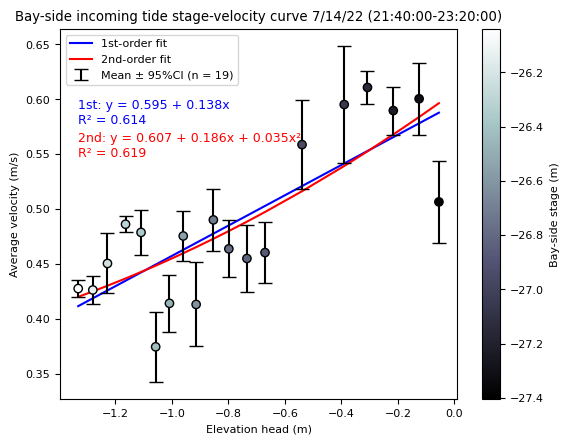

In [50]:
bay_outputs_filtered = dropmissing(bay_outputs)
bay_outputs_filtered = filter(row -> row.Z < 0, bay_outputs_filtered)

bay_SEMs = [NaNStatistics.nanstd(v) / sqrt(count(!isnan, v)) for v in bay_outputs_filtered.velocities]
import Polynomials

plt.figure()
plt.xlabel("Elevation head (m)")
plt.ylabel("Average velocity (m/s)")
plt.title("Bay-side incoming tide stage-velocity curve 7/14/22 ($(Dates.Time(bay_outputs_filtered.times[1]))-$(Dates.Time(bay_outputs_filtered.times[end])))")

p_x = bay_outputs_filtered.Z
p_y = Statistics.mean.(bay_outputs_filtered.velocities)
# First-order polynomial fit (linear)
p1 = Polynomials.fit(p_x, p_y, 1)
y_fit1 = p1.(p_x)
ss_res1 = sum((p_y .- y_fit1).^2)
ss_tot = sum((p_y .- mean(p_y)).^2)
r2_1 = 1 - ss_res1 / ss_tot

# Second-order polynomial fit (quadratic)
p2 = Polynomials.fit(p_x, p_y, 2)
y_fit2 = p2.(p_x)
ss_res2 = sum((p_y .- y_fit2).^2)
r2_2 = 1 - ss_res2 / ss_tot

# Coefficients
c1 = round.(Polynomials.coeffs(p1); digits=3)
c2 = round.(Polynomials.coeffs(p2); digits=3)

# Equations as strings
eq1_str = "1st: y = $(c1[1]) + $(c1[2])x\nR² = $(round(r2_1, digits=3))"
eq2_str = "2nd: y = $(c2[1]) + $(c2[2])x + $(c2[3])x²\nR² = $(round(r2_2, digits=3))"

# Annotate in upper left
annot_x = minimum(p_x)
annot_y = maximum(p_y)

plt.annotate(eq1_str, xy=(annot_x, annot_y-0.01), xycoords="data", fontsize=9, color="blue", verticalalignment="top")
plt.annotate(eq2_str, xy=(annot_x, annot_y - 0.04), xycoords="data", fontsize=9, color="red", verticalalignment="top")

n_points = length(bay_outputs_filtered.velocities)

# Plot fits
plt.plot(p_x, y_fit1, label="1st-order fit", color="blue", zorder = 1)
plt.plot(p_x, y_fit2, label="2nd-order fit", color="red", zorder = 1)
plt.errorbar(bay_outputs_filtered.Z, NaNStatistics.nanmean.(bay_outputs_filtered.velocities), 
    yerr=bay_SEMs, fmt="none", capsize=5, label="Mean ± 95%CI (n = $n_points)", color="black", zorder = 2)
plt.scatter(bay_outputs_filtered.Z, NaNStatistics.nanmean.(bay_outputs_filtered.velocities), 
    c = bay_outputs_filtered.WSE_gage, cmap = "bone", zorder = 3, edgecolors = "black")

# Labels and legend
plt.legend(loc="upper left")
plt.colorbar(label = "Bay-side stage (m)")
plt.gcf()


In [37]:
bay_SEMs = [NaNStatistics.nanstd(v) / sqrt(count(!isnan, v)) for v in bay_outputs_filtered.velocities]

19-element Vector{Float64}:
 0.037179105460470305
 0.03284038893294839
 0.021848853610469066
 0.015378605212856817
 0.05342988722862374
 0.04086302397480551
 0.028051510344380786
 0.030170747504154116
 0.02595086698517794
 0.028513960465304418
 0.038311952884761885
 0.022956259526705245
 0.025898830355833048
 0.03200143804034624
 0.02077926391238445
 0.007500501020900519
 0.027324788809280166
 0.012556200296136981
 0.007382326542822885

In [ ]:
#### STREAMLINE METHOD 2 - MQD VECTOR FIELD

# Modifying downstream IRQIV code for same file as variance image

# Select file: 
filenum = 3492
# filenum = 3504

# Subwindow dimensions remain constant
const M=32 # subwindow dims - horiz, N = vert.
const N=32
# Search radius - variance STIV lines steeper slopes approx 35pix/frame
const rhoI = 38 # how far away to search (+/-) - i=short side, j= long side
const rhoJ = 38 # Set these to visual estimates - plot one pair
MQD_parameters = (M=M, N=N, rhoI=rhoI, rhoJ=rhoJ)

# Set ATS parameters
Img_dims = [784, 1344] # Image dims: 784 x 1344
DtFrames = 1                    # Δt, frames (ATS 3116 is at 10Hz)
data_output_rate_frames = 1    # difference between I1 sequence, frames - time sep of output
nImagePairs = 100 # can set to inf - all frames in file
Nfiles = 40 # Set number of files to average over

# Load IR images:
I1inds = range(1, step=data_output_rate_frames, length=nImagePairs)
I2inds = I1inds .+ DtFrames

# Crop AOI to area just outside sluicegate
left_crop = 900

subwincorners = CartesianIndices(( (N+rhoI):N:(Img_dims[1]-(N+rhoI+1)),
                                    left_crop:M:(Img_dims[2]-(M+rhoJ+1))))

FLIR_filename = joinpath("/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-00" * string.(filenum) * ".ats")
ats_year = 2022
@assert isfile(FLIR_filename)
I1images = LoadATSImageSequence(FLIR_filename, I1inds, ats_year)
I2images = LoadATSImageSequence(FLIR_filename, I2inds, ats_year)

# Run MQD

# Remove image pairs when at least one image took place during NUC (calibration)
# mode:
if any(isnuc(I1images.Headers)) || any(isnuc(I2images.Headers))
    nuc_frames = isnuc(I1images.Headers) .| isnuc(I2images.Headers)
    I1inds = I1inds[.!( isnuc(I1images.Headers) .| isnuc(I2images.Headers) )]
    I2inds = I2inds[.!( isnuc(I1images.Headers) .| isnuc(I2images.Headers) )]
    I1images = LoadATSImageSequence(FLIR_filename, I1inds, ats_year)
    I2images = LoadATSImageSequence(FLIR_filename, I2inds, ats_year)
end

# Initialize MQD calculation:
MQD_variables = initialize_MQD(I1images,
                            I2images,
                            subwincorners,
                            N, M,
                            rhoI, rhoJ)                              

# Perform the MQD analysis:
subpix_shifts_i, subpix_shifts_j, performance_message = perform_MQD(
    I1images, I2images, subwincorners, MQD_variables)

mean_shifts_i = dropdims(NaNStatistics.nanmean(subpix_shifts_i, dims = 3), dims = 3)
mean_shifts_j = dropdims(NaNStatistics.nanmean(subpix_shifts_j, dims = 3), dims = 3)

# Plotting in pixel space (generate indices for vector locations) - issue w/ CSV package in multithread mode
x_vector = [index[2] for index in subwincorners]
y_vector = [index[1] for index in subwincorners]

1.0%┣▍                                         ┫ 1/100 [00:06<Inf:Inf, InfGs/it]
9.0%┣████▎                                          ┫ 9/100 [00:07<01:22, 1it/s]
17.0%┣███████▋                                     ┫ 17/100 [00:08<00:39, 2it/s]
23.0%┣██████████▍                                  ┫ 23/100 [00:08<00:27, 3it/s]
25.0%┣███████████▎                                 ┫ 25/100 [00:08<00:26, 3it/s]
32.0%┣██████████████▍                              ┫ 32/100 [00:08<00:18, 4it/s]
33.0%┣██████████████▉                              ┫ 33/100 [00:08<00:18, 4it/s]
37.0%┣████████████████▋                            ┫ 37/100 [00:09<00:15, 4it/s]
39.0%┣█████████████████▌                           ┫ 39/100 [00:09<00:14, 4it/s]
43.0%┣███████████████████▍                         ┫ 43/100 [00:09<00:13, 5it/s]
44.0%┣███████████████████▉                         ┫ 44/100 [00:09<00:12, 5it/s]
49.0%┣██████████████████████                       ┫ 49/100 [00:09<00:10, 5it/s]
50.0%┣██████████████████████

Performance stats (MQD loop only)
time [s]                       12.777585
subwins/s             1972.2036675944632
allocations [GB]                    9.94
allocations [MB/subwin]               39.43
time [m]                            0.21
total n subwindows                 25200
n image pairs                        100
n subwindows in FOV                  252
size(subwindows)                (21, 12)
M, N                            (32, 32)
rhoI, rhoJ                      (38, 38)
allocations [B]               9937364461
allocations [MB]                 9937.36
gc time [s]                  1.569563709
gc stats            Base.GC_Diff(9937364461, 101226, 1, 8189885, 31562, 98136, 1569563709, 10, 0)
number of threads                      8
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     449313 s          0 s     256759 s     933402 s          0 s
#2  2400 MHz     437516 s          0 s     241138 s 

21×12 Matrix{Int64}:
  70   70   70   70   70   70   70   70   70   70   70   70
 102  102  102  102  102  102  102  102  102  102  102  102
 134  134  134  134  134  134  134  134  134  134  134  134
 166  166  166  166  166  166  166  166  166  166  166  166
 198  198  198  198  198  198  198  198  198  198  198  198
 230  230  230  230  230  230  230  230  230  230  230  230
 262  262  262  262  262  262  262  262  262  262  262  262
 294  294  294  294  294  294  294  294  294  294  294  294
 326  326  326  326  326  326  326  326  326  326  326  326
 358  358  358  358  358  358  358  358  358  358  358  358
   ⋮                        ⋮                        ⋮  
 454  454  454  454  454  454  454  454  454  454  454  454
 486  486  486  486  486  486  486  486  486  486  486  486
 518  518  518  518  518  518  518  518  518  518  518  518
 550  550  550  550  550  550  550  550  550  550  550  550
 582  582  582  582  582  582  582  582  582  582  582  582
 614  614  614  614  6

In [5]:
# plt.close("all")
# fig,axs = plt.subplots()
# axs.quiver(x_vector, y_vector, mean_shifts_j[:,:], mean_shifts_i[:,:], angles="xy")
# axs.invert_yaxis()
# plt.plot([ds_shadow_start[1], ds_shadow_end[1]], [ds_shadow_start[2], ds_shadow_end[2]], label="Diagonal Line", linewidth=2.5)
# plt.scatter(initial_cols, initial_rows)
# plt.gcf()

In [6]:
# # Visualize frames - SKIP
# # Create a plot window and display the initial image
# fig, ax = plt.subplots()
# im = ax.imshow(I1images[1], cmap="viridis", vmin=10000, vmax=10100)

# # Function to update the image
# function update_image!(new_img)
#     plt.imshow(new_img, cmap="viridis", vmin=10000, vmax=11000)
#     plt.draw()          # Force an update
#     plt.pause(0.001)
# end

# # Close all existing plot windows (optional, if needed)
# plt.close("all")

# # Update the image in a loop
# for i in 1:length(I1images)
#     img = I1images[i]
#     update_image!(img)
#     plt.title("$i")
# end

# plt.gcf()

In [8]:
# Define initial conditions from which to start numerical integration of vector field

# Convert to tuples and take the first (row) component, then add half the subwindow dimension
vertical_indices = round.(Int, [Tuple(I)[1] for I in subwincorners][1:end-1,1].+(N/2))

# Iterate by adding indices until at least 20 streamlines have length of at least 20 pix (need 28 points):
vertical_indices = round.(Int,collect(range(first(vertical_indices), last(vertical_indices), length=28)))

ds_shadow_start = [1260, 1]  # [u, v]
ds_shadow_end = [1090, 784]  # [u, v]
shadow_slope = (ds_shadow_end[2] - ds_shadow_start[2]) / (ds_shadow_end[1] - ds_shadow_start[1])

# Offset distance (horizontal left shift) - set to 0 to integrate upstream from shadow line
offset_distance = 0  # Pixels

# Find horizontal coordinates along the diagonal line for each vertical index
initial_conditions = []
for v in vertical_indices
    # Horizontal coordinate on the diagonal line at the given vertical coordinate
    col_on_diagonal = ds_shadow_start[1] + (v - ds_shadow_start[2]) / shadow_slope
    
    # Shift directly left by subtracting the offset distance
    col_shifted = col_on_diagonal - offset_distance
    
    # Add the shifted point as an initial condition
    push!(initial_conditions, (v, round(Int, col_shifted)))
end

initial_conditions
initial_rows, initial_cols = zip(initial_conditions...) |> collect

2-element Vector{NTuple{28, Int64}}:
 (86, 109, 131, 154, 176, 199, 221, 244, 266, 289, 311, 334, 356, 379, 401, 424, 446, 469, 491, 514, 536, 559, 581, 604, 626, 649, 671, 694)
 (1242, 1237, 1232, 1227, 1222, 1217, 1212, 1207, 1202, 1197, 1193, 1188, 1183, 1178, 1173, 1168, 1163, 1158, 1154, 1149, 1144, 1139, 1134, 1129, 1124, 1119, 1115, 1110)

[86.0 1242.0; 84.9919058743583 1241.9386215895663; 84.9919058743583 1241.9386215895663][109.0 1237.0; 107.56206508028227 1237.339537270241; 107.56206508028227 1237.339537270241][131.0 1232.0; 129.43968893180244 1232.4566573782542; 129.43968893180244 1232.4566573782542][154.0 1227.0; 152.45355774835943 1227.506215454911; 152.45355774835943 1227.506215454911][176.0 1222.0; 174.25753129870938 1222.701070455477; 174.25753129870938 1222.701070455477][199.0 1217.0; 196.94043058790137 1217.8588379467988; 196.94043058790137 1217.8588379467988][221.0 1212.0; 219.28086055246504 1212.2502395390334; 207.9644311805304 1214.8632533766572; 186.36497716900595 1223.4277072913899; 186.36497716900595 1223.4277072913899][244.0 1207.0; 241.96175677263076 1206.9554986939636; 229.14840586342152 1207.1940574744158; 219.54950627943745 1208.2563487524078; 185.98495555621668 1218.70943241857; 169.68816188502635 1225.3030685557958; 169.68816188502635 1225.3030685557958][266.0 1202.0; 263.4050827364539 1201.750089

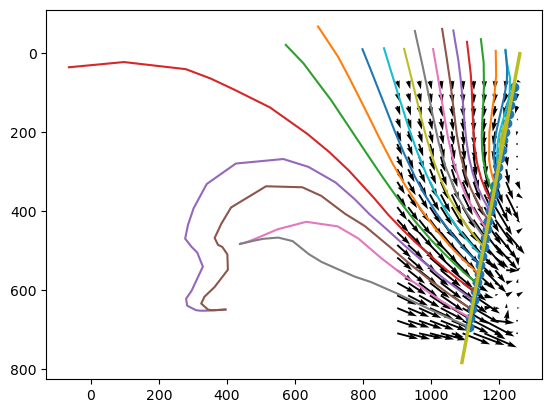

In [ ]:
# Ensure data is in Float64 format
i = Float64[y_vector[:,1]...]
j = Float64[x_vector[1,:]...]

# # Check dimensions
# println("Dimensions of i: ", length(i))
# println("Dimensions of j: ", length(j))

# Create linear interpolants for the vector field - make i & j shifts negative to integrate upstream
u_interp = extrapolate(interpolate((i, j), -mean_shifts_i, Gridded(Linear())), Line())
v_interp = extrapolate(interpolate((i, j), -mean_shifts_j, Gridded(Linear())), Line())

# Define initial conditions and time span
initial_conditions = [StaticArrays.SA[sp[1], sp[2]] for sp in initial_conditions]

# Store coordinates of all streamlines
shadow_interp = LinearInterpolation(Float64[ds_shadow_start[2], ds_shadow_end[2]], 
                            Float64[ds_shadow_start[1], ds_shadow_end[1]]; extrapolation_bc=Line())

# Compute streamlines for all starting points
all_streamline_coords = [] # Initialize default array
for sp in initial_conditions
    compute_streamline(sp)
end

# Plot the vector field using quiver
X, Y = meshgrid(j, i)

fig, ax = plt.subplots()
ax.quiver(X, Y, mean_shifts_j, mean_shifts_i, angles="xy") # Why the ' on U and V?

# Plot all streamlines
for coords in all_streamline_coords
    x_coords = [coord[2] for coord in coords]
    y_coords = [coord[1] for coord in coords]
    ax.plot(x_coords, y_coords)# , label="Streamline")
end

# Set labels and title
ax.invert_yaxis()  # To match the coordinate system of the matrices
# ax.legend()
plt.plot([ds_shadow_start[1], ds_shadow_end[1]], [ds_shadow_start[2], ds_shadow_end[2]], label="Diagonal Line", linewidth=2.5)
plt.scatter(initial_cols, initial_rows)

# Show the plot
plt.gcf()

In [10]:
# Convert streamlines to pixel coordinates

# Define a vector of sets, one for each streamline
StreamlinePixelsSingle = []

# Diagonal line endpoints
x_start, y_start = ds_shadow_start
x_end, y_end = ds_shadow_end

# Set pixel intensity limits for figure
vmin_val = 10400
vmax_val = 10800

# Iterate through each streamline in `all_streamline_coords`
for coords in all_streamline_coords
    # Define a set to store unique pixels for the current streamline
    streamline_pixels = []  # Use an ordered vector instead of a set

    for k in 1:length(coords)-1
        y0, x0 = coords[k]
        y1, x1 = coords[k+1]

        # Calculate Bresenham pixels for the current segment
        bresenham_pixels = bresenham_line(round(Int, y0), round(Int, x0), round(Int, y1), round(Int, x1))
        
        # Filter pixels that are beyond the diagonal line
        filtered_pixels = filter(p -> left_of_diagonal(p[2], p[1], x_start, y_start, x_end, y_end), bresenham_pixels)

        # Add pixels to the current streamline set
        append!(streamline_pixels, filtered_pixels)    
    end
    
    # Add the unique set of pixels for this streamline to the overall list
    push!(StreamlinePixelsSingle, streamline_pixels)
end

streamline_lengths = [length(streamline) for streamline in StreamlinePixelsSingle]
print("Shortest streamline is $(minimum(streamline_lengths)) pixels") # See how long shortest streamline is

# (Optional) Convert sets back to arrays if needed
StreamlinePixelsSingle = [collect(streamline) for streamline in StreamlinePixelsSingle]

count(x -> x > 100, length.(StreamlinePixelsSingle))

StreamlinePixelsSingle = [
    reverse(length(streamline) > 100 ? streamline[1:100] : streamline)
    for streamline in StreamlinePixelsSingle if length(streamline) >= 100
]

Shortest streamline is 0 pixels

20-element Vector{Vector{Any}}:
 [(171, 1219), (172, 1218), (173, 1218), (174, 1217), (175, 1217), (176, 1217), (177, 1216), (178, 1216), (179, 1216), (180, 1215)  …  (258, 1202), (259, 1202), (260, 1202), (261, 1202), (262, 1202), (263, 1202), (263, 1202), (264, 1202), (265, 1202), (266, 1202)]
 [(194, 1203), (195, 1202), (196, 1202), (197, 1202), (198, 1201), (199, 1201), (200, 1201), (201, 1200), (202, 1200), (202, 1200)  …  (281, 1196), (282, 1196), (283, 1196), (284, 1196), (285, 1196), (286, 1196), (286, 1196), (287, 1196), (288, 1197), (289, 1197)]
 [(214, 1188), (215, 1188), (216, 1187), (217, 1187), (218, 1187), (219, 1187), (220, 1187), (221, 1186), (222, 1186), (223, 1186)  …  (301, 1190), (302, 1191), (303, 1191), (304, 1191), (305, 1191), (306, 1192), (307, 1192), (308, 1192), (308, 1192), (309, 1192)]
 [(237, 1170), (238, 1170), (239, 1170), (240, 1170), (241, 1170), (242, 1170), (243, 1170), (244, 1170), (245, 1170), (246, 1170)  …  (324, 1184), (325, 1184), (326, 1185),

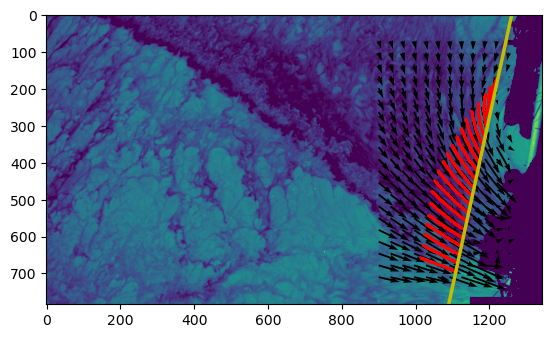

In [11]:
# Plot the vector field using quiver
i = Float64[y_vector[:,1]...]
j = Float64[x_vector[1,:]...]
X, Y = meshgrid(j, i)

# Bresenham line plot
fig, ax = plt.subplots()
plt.imshow(I1images[1], vmin = vmin_val, vmax = vmax_val)#, extent=(left_crop, Img_dims[2], Img_dims[1], 0),cmap="viridis")
# ax.invert_yaxis()  # To match the coordinate system of the matrices
ax.quiver(X, Y, mean_shifts_j, mean_shifts_i, angles="xy")
# Plot all streamlines
# for coords in all_streamline_coords
#     x_coords = [coord[2] for coord in coords]
#     y_coords = [coord[1] for coord in coords]
#     ax.plot(x_coords, y_coords, label="Streamline")
# end

for streamline_pixels in StreamlinePixelsSingle
    for (y, x) in streamline_pixels
        ax.plot(x, y, "ro", markersize=1, label="Streamline Pixels")
    end
end

# Set labels and title
# ax.invert_yaxis()  # To match the coordinate system of the matrices
plt.plot([ds_shadow_start[1], ds_shadow_end[1]], [ds_shadow_start[2], ds_shadow_end[2]-1], label="Diagonal Line", linewidth=2.5, "y")
# plt.scatter(initial_cols, initial_rows, c="y")
# ax.set_title("Vector Field with Streamlines and Bresenham Pixels")
# ax.legend()

# Show the plot
plt.gcf()

In [12]:
# INCORPORATE GEOREFERENCING - bay side
import CSV, Dates, Geodesy
using DataFrames
ft_to_m = 0.3048

# Import dike resurvey data from May 2023
macpath = raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2023/5_23_SiteVisit/Georeferencing/Leica/M_CNRD.TXT"
winpath = raw"C:\Users\evanh\Box\Cornell\CACO\2023\5_23_SiteVisit\Georeferencing\Leica\M_CNRD.TXT"
ft_to_m = 0.3048
CNRD_resurvey = CSV.read(macpath, DataFrames.DataFrame) # Total station recorded in survey ft!!
US_GCP_xyz_resurvey = [CNRD_resurvey[2:7,2] CNRD_resurvey[2:7,3] CNRD_resurvey[2:7,4]] .* ft_to_m
DS_GCP_xyz_resurvey = [CNRD_resurvey[8:12,2] CNRD_resurvey[8:12,3] CNRD_resurvey[8:12,4]] .* ft_to_m

# Convert to geospatial coords using GPS data
antenna_csv = CSV.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2023/5_23_SiteVisit/Georeferencing/InertialSense/20230515_173251_base/LOG_SN40107_20230515_173251_0001_DID_GPS1_RTK_POS.csv", DataFrames.DataFrame)
antenna_lla = Geodesy.LLA(Statistics.mean(antenna_csv."lla[0]"), Statistics.mean(antenna_csv."lla[1]"), Statistics.mean(antenna_csv."lla[2]"))
antenna_utm = Geodesy.UTMZ(antenna_lla, Geodesy.wgs84)

# US_GCP_utm_resurvey = US_GCP_xyz_resurvey + [antenna_utm.x antenna_utm.y antenna_utm.z]
US_GCP_utm_resurvey = US_GCP_xyz_resurvey .+ [antenna_utm.x antenna_utm.y antenna_utm.z] # Add UTM position of antenna to all relative points in m
DS_GCP_utm_resurvey = DS_GCP_xyz_resurvey .+ [antenna_utm.x antenna_utm.y antenna_utm.z] # Add UTM position of antenna to all relative points in m

# Import thermistor data from field campaign

# ChatGPT function to find nearest thermistor times to each ATS file (for WSE)
function find_nearest_time_indices(irregular_times, regular_times)
    nearest_indices = [argmin(abs.(time .- regular_times)) for time in irregular_times]
    return nearest_indices
end

thermpath = raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/Thermistor/P6_CACO_July_2022_truncated.txt"
therm = CSV.read(thermpath, delim = ',', DataFrame)
thermP = therm[:,2] # water surface elevation from thermistor - in dbar?
# # 360 lines per hour, 8640 lines per day
us_therm_cam_offset = (sqrt(9^2-2^2) + 1/3 + 7) * ft_to_m
ds_therm_cam_offset = 209/12*ft_to_m

therm[!,3] = Dates.Date.(therm[!,3], " dd u YYYY")
therm_datetime = Dates.DateTime.(therm[!,3], therm[!,4])
therm = hcat(therm, therm_datetime)
rename!(therm,[:TemperatureC, :PressureM, :Date, :Time, :DateTime])

# Change thermistor elevation relative to camera
therm_moved_bool = (therm.Time .== Dates.Time("08:12:00", "HH:MM:SS")) .& (therm.Date .== Dates.Date("2022-07-14", "yyyy-mm-dd"))
therm_moved_idx = findall(x->x==1, therm_moved_bool)
thermZ = us_therm_cam_offset.-thermP[1:therm_moved_idx[]] # vertical offset from camera to thermistor - 
thermZ = append!(thermZ, ds_therm_cam_offset.-thermP[therm_moved_idx[]+1:end])

therm = hcat(therm, thermZ)
rename!(therm, :x1 => :WaterDistanceFromCameraM)

plt.close("all")
thermT = string.(therm[:,4])
plt.plot(thermT[6302:6302+8638], thermP[6302:6302+8638])
plt.xticks(1:1200:length(thermZ[6302:6302+8638])#, rotation = 45
)
plt.xlabel("Time - July 14, 2022")
plt.ylabel("Thermistor pressure head (m)")
plt.rc("font",size=24)
# plt.gcf()

┌ Warning: thread = 1 warning: parsed expected 6 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV /Users/evanheberlein/.julia/packages/CSV/OnldF/src/file.jl:578


Finished extrinsic calibration:, 18 iterations, max(|ε|)=1e-10, rms(ε₁-ε₀)=2e-11
ExtrinsicCalibrationParameters
  φ: Float64 -0.7853981633974483
  τ: Float64 -2.8654956341943567
  σ: Float64 0.13909594148207133
  f: Float64 1214.2857142857144
  x_c: Float64 411743.0601037771
  y_c: Float64 4.642674180709229e6
  z_c: Float64 -24.093384677637545
dump(χinitial_ds) = nothing
ExtrinsicCalibrationParameters
  φ: Float64 -1.4304548190321396
  τ: Float64 -2.821451967980822
  σ: Float64 0.38292668649731326
  f: Float64 1280.579618118304
  x_c: Float64 411744.6774145493
  y_c: Float64 4.642674015771329e6
  z_c: Float64 -23.93024861855872
dump(χcalculated_ds) = nothing
φ diff (degrees) -  36.95902391469154
τ diff (degrees) -  -2.5235161883184856
σ diff (degrees) -  -13.970472604903899
f diff -  -66.29390383258965
x_c diff (meters) -  -1.6173107721842825
y_c diff (meters) -  0.16493789944797754
z_c diff (meters) -  -0.16313605907882334


┌ Info: Initial guess, χinitial:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:14
┌ Info: Calibrated values, χcalculated:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:17
┌ Info: Difference between calibrated value and initial guess:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:21


  0.001001 seconds (1.72 k allocations: 174.438 KiB)


┌ Info: (411744.63910856453, 411744.61052058137)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411744.62618504453, 411744.66087158065)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411744.63673112454, 411744.7066817419)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411743.92697384453, 411743.94263306085)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411744.04889384453, 411744.1250520601)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411742.5946517856, 411742.3464174061)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (1255.

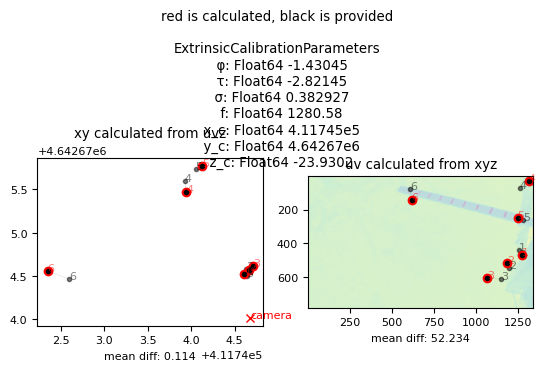

In [15]:
# Camera location calibration - BAY SIDE:
dlt_ds = IRQIV.DLT(χinitial_ds, FLIR_SC8303_17mm)
###############################################################################

χcalculated_ds = ExtrinsicCalibration(
    TrueGCPuv_ds,
    DS_GCP_utm_combined,
    χinitial_ds,
    ι,
    MaxIterations = 50,
    PrintoutStats=true)

# ###############################################################################
@info "Initial guess, χinitial:"
@show dump(χinitial_ds)
# 
@info "Calibrated values, χcalculated:"
@show dump(χcalculated_ds)
# 
# Describe how much the calibration changed each parameter:
@info "Difference between calibrated value and initial guess:"
for (i,x) in enumerate(fieldnames(typeof(χcalculated_ds)))
    if i <= 3
        println("$x diff (degrees) -  $(rad2deg(getfield(χinitial_ds, x) - getfield(χcalculated_ds, x)))")
    elseif i == 4
        println("$x diff -  $(getfield(χinitial_ds, x) - getfield(χcalculated_ds, x))")
    else
        println("$x diff (meters) -  $(getfield(χinitial_ds, x) - getfield(χcalculated_ds, x))")
    end
end

# Extract WSE from thermistor time series using ATS file timestamp
ATS_file_time_ds = IRQIV.ats_ts(IRimages_ds)
therminds_ds = find_nearest_time_indices(ATS_file_time_ds, therm.DateTime)
WSE_mean_ATS_ds = χcalculated_ds.z_c - therm.WaterDistanceFromCameraM[therminds_ds][1]
RectParams_ds = IRQIV.ImageRectification.calculate_image_rectification(Camera.pixel_resolution, ι, χcalculated_ds, WSE_mean_ATS_ds, interpolated_grid_spacing=.1)
rectified_image_ds = RectParams_ds(IRimages_ds)
dlt_calculated = IRQIV.DLT(χcalculated_ds, FLIR_SC8303_17mm)

plt.close("all")
plt.rc("font", size=8)
GraphicallyExploreInitialCalibrationGuess(TrueGCPuv_ds, DS_GCP_utm_combined, χcalculated_ds, ι, IRimages_ds[1])
plt.gcf()



Geotransform: [411731.1838, 0.15015076923076637, 0.0, 4.6426986079e6, 0.0, -0.14986969697091615]
Projection: PROJCS["NAD83(2011) / UTM zone 19N",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6318"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-69],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","6348"]]


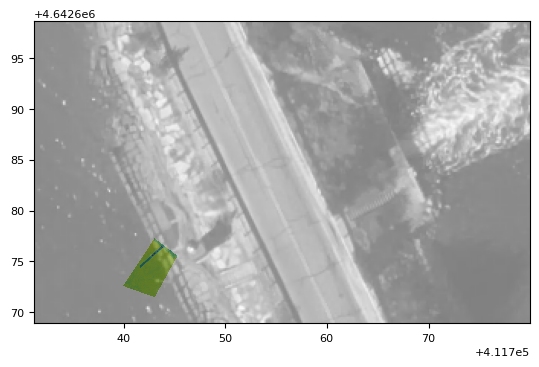

In [16]:
# Test reprojection against basemap imagery

import ArchGDAL
basemap_path = ArchGDAL.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/Analysis/ESRI_basemap/ESRI_basemap.tif")
basemap_band = ArchGDAL.getband(basemap_path, 1)
basemap = ArchGDAL.read(basemap_band)
# basemap = reverse(reverse(basemap, dims=1), dims=2)
basemap = permutedims(basemap, (2, 1)) # 
# basemap = reverse(reverse(basemap, dims=2))

# Get the geotransform (affine transformation to map pixel coordinates to world coordinates)
geotransform = ArchGDAL.getgeotransform(basemap_path)

# Get the dimensions of the image
width = ArchGDAL.width(basemap_path)
height = ArchGDAL.height(basemap_path)

# Extract the geotransform values
x_min = geotransform[1]
y_max = geotransform[4]
x_res = geotransform[2]  # Pixel width
y_res = geotransform[6]  # Pixel height (negative)

# Calculate the extents
x_max = x_min + size(basemap, 2) * x_res
y_min = y_max + size(basemap, 1) * y_res

# Extent for imshow
basemap_extent = (x_min, x_max, y_min, y_max)

# Get the projection (coordinate system)
projection = ArchGDAL.getproj(basemap_path)

println("Geotransform: ", geotransform)
println("Projection: ", projection)

plt.close("all")
plt.imshow(rectified_image_ds, extent=RectParams_ds.extent)
plt.imshow(basemap, extent=basemap_extent, alpha = 0.5, cmap = "gray")
plt.gcf()

In [ ]:
import Images, ImageEdgeDetection
using ImageEdgeDetection: Percentile
import Dates

plt.close("all")

# Loop through all intersecting streamlines and calculate STIV slope

# Preallocate for storing slopes
STIV_averages = zeros(length(StreamlinePixelsSingle))
x_length_averages = zeros(length(StreamlinePixelsSingle))

STIV_time_vec = Dates.Time.(IRQIV.ats_ts(I1images))

ATS_file_time = IRQIV.ats_ts(I1images)
therminds = find_nearest_time_indices(ATS_file_time, therm.DateTime)
WSE_mean_ATS = χcalculated_ds.z_c - therm.WaterDistanceFromCameraM[therminds[1]]

STIV_vels = zeros(length(StreamlinePixelsSingle))

# Loop through each streamline
for (stream_ind, streamline_uv) in enumerate(StreamlinePixelsSingle)
    # Locate the intersection index for trimming
    streamline_uv = remove_duplicate_coords(streamline_uv)

    # Calculate physical locations of STIV lines
    xy_coords = fill((0.0, 0.0), length(streamline_uv))
    for (coord_ind, coord) in enumerate(streamline_uv)
        v_ind, u_ind = coord
        x_coord, y_coord = IRQIV.uvz2xy(u_ind, v_ind, WSE_mean_ATS, dlt_calculated)
        xy_coords[coord_ind] = (x_coord, y_coord)
    end

    # Create empty vector of vectors (each vector is 1 STIV column)
    STIV_vec_raw = Vector{Vector{Float64}}()
    STIV_vec_interp = Vector{Vector{Float64}}()
    dist_vec = nothing

    # Extract pixel values for the trimmed streamline across the image time series
    for img = 1:size(I1images, 3)
        pixel_intensities = zeros(length(streamline_uv))
        for coord = 1:length(streamline_uv)
            i, j = streamline_uv[coord]
            pixel_intensities[coord] = I1images[i, j, img] # (i, j) for row, col order
        end
        push!(STIV_vec_raw, pixel_intensities)
    end

    # Unpack the vector of vectors to a 2D array, subtract mean from each row (pixel noise)
    STIV_vec_raw = hcat(STIV_vec_raw...)
    for row = 1:size(STIV_vec_raw, 1)
        STIV_vec_raw[row, :] = STIV_vec_raw[row, :] .- Statistics.mean(STIV_vec_raw[row, :])
    end

    for ts = 1:size(STIV_vec_raw, 2)
        STIV_vec = STIV_vec_raw[:, ts]
        uniform_distances, interpolated_intensities = interpolate_preserving_points(xy_coords, STIV_vec)
        push!(STIV_vec_interp, interpolated_intensities)

        # Convert distances to vector at first timestep for physical lengths of interpolation
        if ts == 1
            dist_vec = collect(uniform_distances)
        end
    end

    # Assemble STIV pseudoimage
    STIV_vec_interp = hcat(STIV_vec_interp...)

    # Perform edge detection on the STIV image
    STIV_edges = ImageEdgeDetection.detect_edges(STIV_vec_interp, alg)
    STIV_edges = float_to_bool(STIV_edges, 0.5)

    # Label connected components in the detected edges
    STIV_labels, num_components = label_components_8_connected(STIV_edges)

    # Calculate slope for components over a length threshold (e.g. 100 pixels)
    slopes, lengths = calculate_slope_for_components(STIV_labels, num_components, STIV_line_threshold)
    filtered_slopes_lengths = Dict(k => (slope, lengths[k]) for (k, slope) in slopes if slope != 0 && isfinite(slope))
    
    # Filter out detected slopes of 0 or Inf
    STIV_slopes = Dict(k => v[1] for (k, v) in filtered_slopes_lengths)
    # Calculate size of slopes in x dimension using updated slope calc function
    x_lengths = Dict(k => v[2] for (k, v) in filtered_slopes_lengths)

    STIV_averages[stream_ind] = NaNStatistics.nanmean(collect(values(STIV_slopes))) # Stored as a dictionary
    x_length_averages[stream_ind] = NaNStatistics.nanmean(collect(values(x_lengths)))

    # Calculate STIV velocities in physical units 
    STIV_time_average = 1/I1images.Metadata.Estimatedfps * x_length_averages[stream_ind] # Seconds per frame * num of frames
    STIV_vels[stream_ind] = calculate_path_length(xy_coords)/STIV_time_average

    # Plot the results
    u_coords = [coord[2] for coord in streamline_uv]  # x = col index
    v_coords = [coord[1] for coord in streamline_uv]  # y = row index
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    # Plot the original image with the streamline
    im1 = ax1.imshow(I1images[:,:,1], cmap="viridis")  # Show the first frame or another reference image
    ax1.plot(u_coords, v_coords, "r", linewidth=2.5)  # Overlay the streamline in red
    ax1.set_title("Streamline")
    ax1.set_xlabel("U coordinate (pix)")
    ax2.set_ylabel("V coordinate (pix)")

    # Plot the STIV image
    im2 = ax2.imshow(STIV_vec_interp, cmap="viridis")  # Display STIV vector
    ax2.set_title("STIV Image")
    ax2.set_xticks(collect(1:49:nImagePairs))
    ax2.set_xticklabels(string.(STIV_time_vec[1:49:nImagePairs]))
    ax2.set_yticks(collect(1:20:length(dist_vec)))
    ax2.set_yticklabels(round.(dist_vec[1:20:length(dist_vec)], digits = 3))
    ax2.set_xlabel("Time on 7/14/22 (HH:mm:ss.ms)")
    ax2.set_ylabel("Distance (m)")
    
    # Plot the labeled components (slope map)
    im3 = ax3.imshow(STIV_labels, cmap="nipy_spectral")
    ax3.set_title("Labeled Slopes")
    fig.colorbar(im3, ax=ax3, label="Component Label")
    ax3.set_xlabel("Timestep (pix)")
    ax3.set_ylabel("Distance (pix)")

    # plt.tight_layout()
            
    fig.suptitle("STIV Average Velocity: $(round(STIV_vels[stream_ind], digits = 3)) m/s", fontsize=14)
    plt.rc("font",size=12)
end

STIV_vels

plt.show()

2025-03-17 11:16:11.174 julia[76402:4312063] +[IMKClient subclass]: chose IMKClient_Modern
2025-03-17 11:16:11.174 julia[76402:4312063] +[IMKInputSession subclass]: chose IMKInputSession_Modern


In [18]:
import ImageFiltering

streamline_uv = remove_duplicate_coords(StreamlinePixelsSingle[2])

# Calculate physical locations of STIV lines
xy_coords = fill((0.0, 0.0), length(streamline_uv))
for (coord_ind, coord) in enumerate(streamline_uv)
    v_ind, u_ind = coord
    x_coord, y_coord = IRQIV.uvz2xy(u_ind, v_ind, WSE_mean_ATS, dlt_calculated)
    xy_coords[coord_ind] = (x_coord, y_coord)
end

# Create empty vector of vectors (each vector is 1 STIV column)
STIV_vec_raw = Vector{Vector{Float64}}()
STIV_vec_interp = Vector{Vector{Float64}}()
dist_vec = nothing

# Extract pixel values for the trimmed streamline across the image time series
for img = 1:size(I1images, 3)
    pixel_intensities = zeros(length(streamline_uv))
    for coord = 1:length(streamline_uv)
        i, j = streamline_uv[coord]
        pixel_intensities[coord] = I1images[i, j, img] # (i, j) for row, col order
    end
    push!(STIV_vec_raw, pixel_intensities)
end

# Unpack the vector of vectors to a 2D array, subtract mean from each row (pixel noise)
STIV_vec_raw = hcat(STIV_vec_raw...)
for row = 1:size(STIV_vec_raw, 1)
    STIV_vec_raw[row, :] = STIV_vec_raw[row, :] .- Statistics.mean(STIV_vec_raw[row, :])
end

for ts = 1:size(STIV_vec_raw, 2)
    STIV_vec = STIV_vec_raw[:, ts]
    uniform_distances, interpolated_intensities = interpolate_preserving_points(xy_coords, STIV_vec)
    push!(STIV_vec_interp, interpolated_intensities)

    # Convert distances to vector at first timestep for physical lengths of interpolation
    if ts == 1
        dist_vec = collect(uniform_distances)
    end
end

# Assemble STIV pseudoimage
STIV_vec_interp = hcat(STIV_vec_interp...)

# Histogram normalization for contrast enhancement
STIV_vec_normal = (STIV_vec_interp .- minimum(STIV_vec_interp)) ./ (maximum(STIV_vec_interp) - minimum(STIV_vec_interp))
# STIV_vec_normalized = STIV_vec_interp.-minimum(STIV_vec_interp)
STIV_vec_normal = Images.adjust_histogram(STIV_vec_normal, Images.Equalization(nbins = 256))

# Load your STIV image (assume `img` is a grayscale image)
img = STIV_vec_interp

# Define Sobel filters for x and y gradients
sobel_x = [-1 0 1; -2 0 2; -1 0 1]
sobel_y = [-1 -2 -1; 0 0 0; 1 2 1]
sobel_45 = [0 1 2; -1 0 1; -2 -1 0]
sobel_135 = [2 1 0; 1 0 -1; 0 -1 -2]

# Compute gradients
Gx = ImageFiltering.imfilter(img, sobel_x)
Gy = ImageFiltering.imfilter(img, sobel_y)

# Compute gradient magnitude and direction
magnitude = sqrt.(Gx.^2 .+ Gy.^2)
direction = atan.(Gy, Gx)

# Optional: Thresholding gradients
threshold = 200
filtered_magnitude = magnitude .* (magnitude .> threshold)

# Assuming 'filtered_magnitude' and 'filtered_direction' are your gradient magnitude and direction arrays
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 6))

im1 = ax1.imshow(STIV_vec_interp)  # Display STIV vector
ax1.set_title("STIV Image")
ax1.set_xticks(collect(1:49:nImagePairs))
ax1.set_xticklabels(string.(STIV_time_vec[1:49:nImagePairs]))
ax1.set_yticks(collect(1:20:length(dist_vec)))
ax1.set_yticklabels(round.(dist_vec[1:20:length(dist_vec)], digits = 3))
ax1.set_xlabel("Time on 7/14/22 (HH:mm:ss.ms)")
ax1.set_ylabel("Distance (m)")

im2 = ax2.imshow(STIV_vec_normal)  # Display STIV vector
ax2.set_title("STIV Image")
ax2.set_xticks(collect(1:49:nImagePairs))
ax2.set_xticklabels(string.(STIV_time_vec[1:49:nImagePairs]))
ax2.set_yticks(collect(1:20:length(dist_vec)))
ax2.set_yticklabels(round.(dist_vec[1:20:length(dist_vec)], digits = 3))
ax2.set_xlabel("Time on 7/14/22 (HH:mm:ss.ms)")
ax2.set_ylabel("Distance (m)")

# Plot direction
im3 = ax3.imshow(rad2deg.(direction), cmap="Spectral")
fig.colorbar(im3, ax=ax3)
ax3.set_title("Gradient Direction")

# Plot magnitude
im4 = ax4.imshow(filtered_magnitude, cmap="gray")
fig.colorbar(im4, ax=ax4)
ax4.set_title("Gradient Magnitude")

plt.tight_layout()
plt.show()


In [19]:
plt.close()
plt.hist(STIV_vec_normalized[:], 51)
plt.gcf()

# STIV_vec_interp.-minimum(STIV_vec_interp)

UndefVarError: UndefVarError: `STIV_vec_normalized` not defined

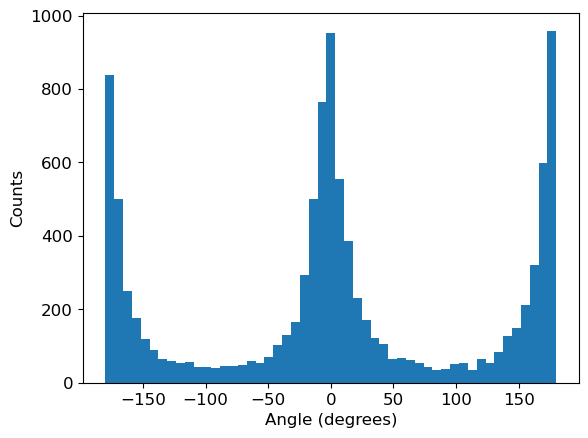

In [20]:
plt.close()

fig, ax = plt.subplots(1,1)
plt.hist(rad2deg.(direction)[:], bins = 51)
plt.gcf()
ax.set_xlabel("Angle (degrees)")
ax.set_ylabel("Counts")
plt.gcf()

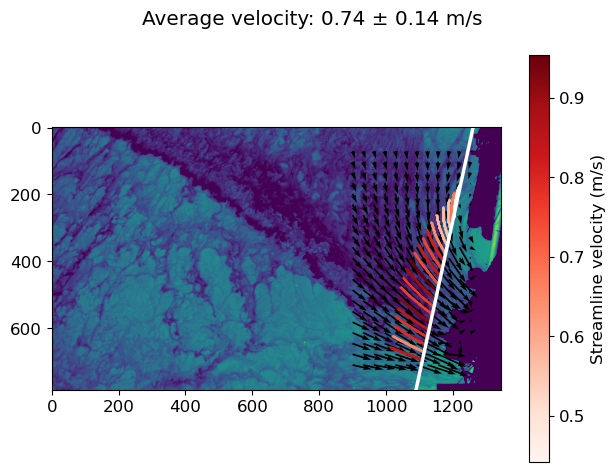

In [21]:
# Add color coded velocity scale to streamline figure

using PyCall
normalize = pyimport("matplotlib.colors").Normalize

min_vel = minimum(STIV_vels)
max_vel = maximum(STIV_vels)
cmap = plt.get_cmap("Reds")  # Choose a colormap (e.g., "viridis")

fig, ax = plt.subplots()
plt.imshow(I1images[1], vmin = vmin_val, vmax = vmax_val)#, extent=(left_crop, Img_dims[2], Img_dims[1], 0),cmap="viridis")
ax.quiver(X, Y, mean_shifts_j, mean_shifts_i, angles="xy")

for (i, streamline_pixels) in enumerate(StreamlinePixelsSingle)
    velocity = STIV_vels[i]
    streamline_color = cmap((velocity - min_vel) / (max_vel - min_vel))  # Map to 0–1 range for the colormap
    # dump((velocity - min_vel) / (max_vel - min_vel))
    for (y, x) in streamline_pixels
        ax.plot(x, y, marker="o", color=streamline_color, markersize=.5, label="Streamline Pixels")
    end
end

# Set labels and title
plt.plot([ds_shadow_start[1], ds_shadow_end[1]], [ds_shadow_start[2], ds_shadow_end[2]-1], label="Diagonal Line", linewidth=2.5, "w")

# Add a colorbar
norm = normalize(vmin=min_vel, vmax=max_vel)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Streamline velocity (m/s)")
fig.suptitle("Average velocity: $(round(mean(STIV_vels), digits = 2)) ± $(round(std(STIV_vels), digits = 2)) m/s")

plt.tight_layout()
plt.gcf()

In [ ]:
# Compare with normal component of MQD vectors

# Calculate physical dimensions of vector field
displacement_x, displacement_y, centroid_x_origin, centroid_y_origin = pixel2physical_displacements(subwincorners, 
                                                                                                        mean_shifts_i, 
                                                                                                        mean_shifts_j, 
                                                                                                        M, N, 
                                                                                                        WSE_mean_ATS,
                                                                                                        dlt_calculated)


ds_transect_start_u = ds_shadow_start[1] - M - rhoJ # subtract here bc shadow on rhs of image - us it was on lhs
ds_transect_start_v = ds_shadow_start[2] + N + rhoI # First point in vertical pixels - edge of image + search radius + subwindow size
# [ds_transect_start_u, ds_transect_start_v]
ds_transect_end_v = ds_shadow_end[2] - N - rhoI

# Find angle of shadow theta
ds_shadow_theta = atan(1/shadow_slope)

# Select subwindows for quantification
subwin_inds_vec = hcat(vec(getindex.(subwincorners,2)), vec(getindex.(subwincorners,1))) # [u, v]

# Filter by row in v coordinate :
subwin_v_coords = getindex.(subwincorners,1)[:,1] # vector of subwindow v pixel coordinates (vertical)
subwin_u_coords = getindex.(subwincorners,2)[1,:] # vector of subwindow u pixel coordinates (horizontal)

subwin_diag_u_inds = zeros(1:length(subwin_v_coords))
subwin_diag_u_inds[1] = findlast(subwin_u_coords .<= ds_transect_start_u) # index in horiz of last subwindow located <= from transect start at top of image

# find u coordinate for each subwindow along diagonal to have one subwindow in each row of v
subwin_diag_u = subwin_u_coords[Int(subwin_diag_u_inds[1])] # find starting u coordinate

for i = 2:length(subwin_v_coords) # for every row in v 
    subwin_diag_u = subwin_diag_u + N/shadow_slope # from previous u coordinate, go 
    subwin_diag_u_inds[i] = findlast(subwin_u_coords .<= subwin_diag_u)
end

subwin_diag_u_inds
subwin_diag_v_inds = vec(1:length(subwin_v_coords))

# Create mask to isolate indices of subwindows of interest
subwin_mask = zeros(size(subwincorners))
replace!(subwin_mask, 0=>NaN)

for u = 1:size(subwin_mask,2)
    for v = 1:size(subwin_mask,1)
        u_ind = subwin_diag_u_inds[v] # 15
        v_ind = subwin_diag_v_inds[v]
        if u == u_ind && v == v_ind # find subwindow indices in 2d arrays
            subwin_mask[v,u] = 1
        else
        end
    end
end

displacement_x_masked = displacement_x .* subwin_mask
displacement_y_masked = displacement_y .* subwin_mask
inst_disp = hypot.(displacement_x_masked, displacement_y_masked)
inst_disp_alpha = atan.(displacement_y_masked./displacement_x_masked)
inst_disp_field_normal = inst_disp .* cos.(inst_disp_alpha .- ds_shadow_theta)

dt = 1/I1images.Metadata.Estimatedfps
normal_vel_profile = NaNStatistics.nanmean(inst_disp_field_normal, dims = (2)) ./ dt

mean_shifts_i_masked = mean_shifts_i .* subwin_mask
mean_shifts_j_masked = mean_shifts_j .* subwin_mask
fig, ax = plt.subplots()
plt.imshow(I1images[1], vmin = vmin_val, vmax = vmax_val)#, extent=(left_crop, Img_dims[2], Img_dims[1], 0),cmap="viridis")
ax.quiver(X, Y, mean_shifts_j_masked, mean_shifts_i_masked, angles="xy")
plt.plot([ds_shadow_start[1], ds_shadow_end[1]], [ds_shadow_start[2], ds_shadow_end[2]-1], label="Diagonal Line", linewidth=2.5, "w")
fig.suptitle("Average velocity: $(round(mean(normal_vel_profile), digits = 2)) m/s")
plt.gcf()